# **IMPORT LIBRARY**

In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.9 MB/s eta 0:00:00


In [ ]:
import csv
import pandas as pd
from google.colab import files

# Data manipulation
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Handling imbalance
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from feature_engine.encoding import DecisionTreeEncoder
from scipy.stats import skew

# Machine learning models
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **UPLOAD DATASET**

In [ ]:
uploaded = files.upload()

In [ ]:
df = pd.read_excel("/content/final_bersih.xlsx")
df

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.518751,0.175801,0.793815,3.850012,0.094419,0.026629,...,0,0,3.186095e+13,-0.247959,-0.181677,0.592113,0.347827,0.272726,1.030989,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.531879,0.182500,0.782868,3.605489,0.090249,0.033469,...,0,0,3.576791e+13,0.476147,-0.180595,0.624371,0.194311,0.291223,0.929309,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.413048,0.148011,0.764963,3.254654,0.100651,0.034769,...,0,0,4.493729e+13,0.170275,-0.267046,0.525229,0.081062,0.322615,0.661859,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.453454,0.215821,0.763174,3.222509,0.083316,0.022879,...,0,0,4.656256e+13,-0.176303,-0.256379,0.599780,0.310313,0.325833,0.979548,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.594182,0.302629,0.762792,3.215715,0.135364,0.042050,...,0,0,5.004302e+13,0.215795,-0.180836,0.514932,0.060414,0.326521,0.721031,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.373730,0.892889,0.228559,0.296276,0.015648,0.004017,...,0,0,1.580197e+13,-0.137184,2.517534,0.425002,0.189754,3.543991,6.676281,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.292272,1.053327,0.246145,0.326514,0.007099,0.002052,...,0,0,1.614948e+13,0.150845,2.833512,0.427513,0.079557,3.215784,6.556366,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.857900,0.987579,0.221448,0.284435,0.011745,0.003224,...,0,0,1.646801e+13,-0.031710,2.379019,0.448661,0.071376,3.691530,6.590586,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.767676,0.067719,0.258921,0.349384,0.097834,0.027869,...,0,0,1.678707e+13,0.057952,2.488318,0.527581,0.238743,3.005291,6.259933,Perusahaan Sehat


In [ ]:
cols_to_round = ["Current_Ratio", "Cash_Ratio", "DAR", "DER", "NPM", "ROA", "Kepemilikan_Mayoritas",
                 "Insider_Ownership"]
df[cols_to_round] = df[cols_to_round].round(2)

In [ ]:
# #Rapikan nama kolom
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# Simpan ke Excel dgn format desimal
df.to_excel("hasil.xlsx", float_format="%.2f", index=False)

In [ ]:
df

,sub_sektor,no,nama_perusahaan,tahun,current_ratio,cash_ratio,dar,der,npm,roa,...,tmt_education_dk,tmt_education_dd,total_asset,pertumbuhan_revenue,z_score_x1,z_score_x2,z_score_x3,z_score_x4,z_score,label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,3.186095e+13,-0.247959,-0.181677,0.592113,0.347827,0.272726,1.030989,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,3.576791e+13,0.476147,-0.180595,0.624371,0.194311,0.291223,0.929309,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,4.493729e+13,0.170275,-0.267046,0.525229,0.081062,0.322615,0.661859,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,4.656256e+13,-0.176303,-0.256379,0.599780,0.310313,0.325833,0.979548,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,5.004302e+13,0.215795,-0.180836,0.514932,0.060414,0.326521,0.721031,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,1.580197e+13,-0.137184,2.517534,0.425002,0.189754,3.543991,6.676281,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,1.614948e+13,0.150845,2.833512,0.427513,0.079557,3.215784,6.556366,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,1.646801e+13,-0.031710,2.379019,0.448661,0.071376,3.691530,6.590586,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,1.678707e+13,0.057952,2.488318,0.527581,0.238743,3.005291,6.259933,Perusahaan Sehat


In [ ]:
# Hapus spasi depan & belakang pada semua header
df.columns = df.columns.str.strip()

# Hapus spasi kiri-kanan di seluruh DataFrame
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x) # type: ignore

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sub_sektor             1171 non-null   object 
 1   no                     1171 non-null   int64  
 2   nama_perusahaan        1171 non-null   object 
 3   tahun                  1171 non-null   int64  
 4   current_ratio          1171 non-null   float64
 5   cash_ratio             1171 non-null   float64
 6   dar                    1171 non-null   float64
 7   der                    1171 non-null   float64
 8   npm                    1171 non-null   float64
 9   roa                    1171 non-null   float64
 10  roe                    1171 non-null   float64
 11  kepemilikan_mayoritas  1171 non-null   float64
 12  komisaris_independen   1171 non-null   int64  
 13  insider_ownership      1171 non-null   float64
 14  boc_size               1171 non-null   int64  
 15  boc_

In [ ]:
df.isna().sum()

,0
sub_sektor,0
no,0
nama_perusahaan,0
tahun,0
current_ratio,0
cash_ratio,0
dar,0
der,0
npm,0
roa,0


In [ ]:
df = df.replace('-', 0)

Pengcek-kan apakah masih ada nilai selain angka didalam dataset

In [ ]:
df["tmt_education_dd"].replace("", np.nan, inplace=True)

# Imputasi berdasarkan Nama_Perusahaan dengan modus
df["tmt_education_dd"] = (
    df.groupby("nama_perusahaan")["tmt_education_dd"]
        .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
)

In [ ]:
df.iloc[688]

,688
sub_sektor,Asuransi Umum
no,85
nama_perusahaan,PT Asuransi Jasaraharja Putera
tahun,2024
current_ratio,2.04
cash_ratio,0.41
dar,0.67
der,2.02
npm,0.15
roa,0.03


In [ ]:
# Konversi tipe data numerik
cols = ["cash_ratio", "dar", "der", "npm", "roa", "roe", "kepemilikan_mayoritas", "pertumbuhan_revenue"]

# Loop melalui setiap kolom dan lakukan konversi
for col in cols:
    df[col] = (
        df[col]
        .astype(str)                         # pastikan string
        .str.replace(",", "", regex=False)   # hapus koma (pemisah ribuan)
        .replace(["", " "], np.nan)          # kosong jadi NaN
        .astype(float)                       # konversi ke float
    )

Memperbaiki kolom fitur Total_Asset

In [ ]:
# Bersihkan dan konversi Total_Asset dulu
df['total_asset'] = (
    df['total_asset']
    .astype(str)                          # pastikan string
    .str.replace(',', '', regex=False)    # hapus koma
    .replace('', '0')                     # ganti kosong jadi 0 kalau ada
    .astype('float')              # ubah ke float dulu
    .astype('int64')                      # konversi ke int64
)

In [ ]:
# Daftar kolom yang mau dicek
cols = ["cash_ratio", "dar", "der", "npm", "roa", "roe", "kepemilikan_mayoritas", "pertumbuhan_revenue","insider_ownership","komisaris_independen"]

# Regex untuk cek apakah value berupa angka valid
pattern = re.compile(r'^[0-9]*\.?[0-9]+$')

for col in cols:
    mask = ~df[col].astype(str).str.match(pattern)   # nilai yang bukan angka murni
    if mask.any():
        print(f"\nKolom {col} ada data non-numerik:")
        print(df.loc[mask, col])


Kolom der ada data non-numerik:
150      -10.04
171       -6.19
172       -4.45
173       -3.42
174       -2.06
175       -1.78
633      -33.63
1131   -3976.61
1132      -5.97
Name: der, dtype: float64

Kolom npm ada data non-numerik:
5      -0.03
6      -0.04
7      -0.07
32     -1.61
33     -1.47
        ... 
1128   -0.11
1129   -0.13
1132   -0.48
1141   -0.10
1146   -0.03
Name: npm, Length: 230, dtype: float64

Kolom roa ada data non-numerik:
5      -0.01
6      -0.01
7      -0.02
32     -0.05
33     -0.17
        ... 
1128   -0.07
1129   -0.07
1132   -0.15
1141   -0.03
1146   -0.01
Name: roa, Length: 232, dtype: float64

Kolom roe ada data non-numerik:
5        -0.034907
6        -0.049489
7        -0.095409
32       -0.051624
33       -0.187734
           ...    
1128     -0.756360
1129   -109.047570
1131   -374.189765
1141     -0.128611
1146     -0.024841
Name: roe, Length: 225, dtype: float64

Kolom pertumbuhan_revenue ada data non-numerik:
0      -0.247959
3      -0.176303
7  

In [ ]:
df[["komisaris_independen", "boc_size", "boc_education","tmt_size_dk","tmt_size_dd","tmt_education_dk","tmt_education_dd","total_asset"]] = df[["komisaris_independen", "boc_size", "boc_education","tmt_size_dk","tmt_size_dd","tmt_education_dk","tmt_education_dd","total_asset"]].astype(int)

In [ ]:
df['total_asset'].value_counts()

,count
total_asset,
2337953000000,2
438728480000,1
965173000000,1
842799000000,1
693414000000,1
...,...
14646070810000,1
15534781440000,1
15860037150000,1


In [ ]:
cols = ["komisaris_independen", "boc_size", "boc_education",
        "tmt_size_dk","tmt_size_dd","tmt_education_dk",
        "tmt_education_dd"]

for col in cols:
    mask = ~df[col].astype(str).str.fullmatch(r"-?\d+")  # hanya angka bulat (bisa negatif)
    if mask.any():
        print(f"\nKolom {col} ada data bermasalah:")
        print(df.loc[mask, col])

In [ ]:
df[["cash_ratio", "dar", "der","npm","roa","roe","kepemilikan_mayoritas","pertumbuhan_revenue","insider_ownership"]] = df[["cash_ratio", "dar", "der","npm","roa","roe","kepemilikan_mayoritas","pertumbuhan_revenue","insider_ownership"]].astype(float)

In [ ]:
df['total_asset'] = df['total_asset'].abs()

In [ ]:
df['total_asset'].value_counts()

,count
total_asset,
2337953000000,2
438728480000,1
965173000000,1
842799000000,1
693414000000,1
...,...
14646070810000,1
15534781440000,1
15860037150000,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sub_sektor             1171 non-null   object 
 1   no                     1171 non-null   int64  
 2   nama_perusahaan        1171 non-null   object 
 3   tahun                  1171 non-null   int64  
 4   current_ratio          1171 non-null   float64
 5   cash_ratio             1171 non-null   float64
 6   dar                    1171 non-null   float64
 7   der                    1171 non-null   float64
 8   npm                    1171 non-null   float64
 9   roa                    1171 non-null   float64
 10  roe                    1171 non-null   float64
 11  kepemilikan_mayoritas  1171 non-null   float64
 12  komisaris_independen   1171 non-null   int64  
 13  insider_ownership      1171 non-null   float64
 14  boc_size               1171 non-null   int64  
 15  boc_

In [ ]:
df.isna().sum()

,0
sub_sektor,0
no,0
nama_perusahaan,0
tahun,0
current_ratio,0
cash_ratio,0
dar,0
der,0
npm,0
roa,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no,1171.0,7.289069e+01,4.179001e+01,2.000000e+00,3.700000e+01,7.200000e+01,1.080000e+02,1.480000e+02
tahun,1171.0,2.019967e+03,2.761101e+00,2.015000e+03,2.018000e+03,2.020000e+03,2.022000e+03,2.024000e+03
current_ratio,1171.0,3.723117e+00,1.168067e+01,4.000000e-02,1.005000e+00,2.190000e+00,3.700000e+00,3.351900e+02
cash_ratio,1171.0,1.122553e+00,9.615405e+00,0.000000e+00,9.000000e-02,2.300000e-01,5.250000e-01,2.897700e+02
dar,1171.0,6.100171e-01,2.197255e-01,0.000000e+00,4.950000e-01,6.600000e-01,7.600000e-01,1.500000e+00
der,1171.0,9.951153e-01,1.259163e+02,-3.976610e+03,1.060000e+00,1.950000e+00,3.210000e+00,1.641970e+03
npm,1171.0,3.577284e-02,3.963118e-01,-8.150000e+00,0.000000e+00,6.000000e-02,1.500000e-01,1.760000e+00
roa,1171.0,2.415884e-02,3.102476e-01,-3.400000e-01,0.000000e+00,2.000000e-02,4.000000e-02,1.039000e+01
roe,1171.0,-3.657418e-01,1.139507e+01,-3.741898e+02,3.835809e-03,5.572792e-02,1.274669e-01,4.319225e+00
kepemilikan_mayoritas,1171.0,7.417079e-01,2.767321e-01,0.000000e+00,5.800000e-01,8.000000e-01,9.900000e-01,1.000000e+00


In [ ]:
df.to_csv('datayes.csv', index=False)

# **DATA PREPROCESSING**

In [ ]:
data = pd.read_csv('datayes.csv')
data

,sub_sektor,no,nama_perusahaan,tahun,current_ratio,cash_ratio,dar,der,npm,roa,...,tmt_education_dk,tmt_education_dd,total_asset,pertumbuhan_revenue,z_score_x1,z_score_x2,z_score_x3,z_score_x4,z_score,label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.247959,-0.181677,0.592113,0.347827,0.272726,1.030989,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.476147,-0.180595,0.624371,0.194311,0.291223,0.929309,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.170275,-0.267046,0.525229,0.081062,0.322615,0.661859,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.176303,-0.256379,0.599780,0.310313,0.325833,0.979548,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.215795,-0.180836,0.514932,0.060414,0.326521,0.721031,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,15801971000000,-0.137184,2.517534,0.425002,0.189754,3.543991,6.676281,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,16149482000000,0.150845,2.833512,0.427513,0.079557,3.215784,6.556366,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,16468014000000,-0.031710,2.379019,0.448661,0.071376,3.691530,6.590586,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,16787071000000,0.057952,2.488318,0.527581,0.238743,3.005291,6.259933,Perusahaan Sehat


In [ ]:
data = data.drop(columns=['no','nama_perusahaan','tahun','z_score','z_score_x1','z_score_x2','z_score_x3','z_score_x4'])

**Menghitung Skewness dan melihat outlier**

In [ ]:
# pilih kolom numerik saja
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# hitung skewness
skewness = data[num_cols].apply(lambda x: skew(x.dropna()))

# contoh outlier counts pakai IQR
outlier_counts = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_counts[col] = ((data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))).sum()

# buat summary dataframe
summary = pd.DataFrame({
    "Skewness": skewness,
    "Outlier_Counts": pd.Series(outlier_counts)
})

print(summary)


                        Skewness  Outlier_Counts
current_ratio          21.464171              97
cash_ratio             24.924931             133
dar                    -0.668718              36
der                   -25.060422             117
npm                    -9.185810             157
roa                    31.925306             105
roe                   -30.931206             127
kepemilikan_mayoritas  -1.099916               0
komisaris_independen   -0.473680             396
insider_ownership       5.663274             126
boc_size               -0.435911             154
boc_education           1.465702              25
tmt_size_dk            -0.435911             154
tmt_size_dd            -0.308209               0
tmt_education_dk        1.465702              25
tmt_education_dd        1.400632              19
total_asset             3.205062             170
pertumbuhan_revenue    17.334234             150


**Interpretasi**

Hasil analisis menunjukkan bahwa beberapa variabel memiliki nilai skewness yang tinggi dan jumlah outlier cukup tinggi. Misalnya, Current Ratio (21,46), Cash Ratio (24,92), dan ROA (31,92) menunjukkan distribusi data yang sangat miring ke kanan, sehingga sebaran datanya tidak normal dan cenderung terkonsentrasi pada nilai tertentu dengan adanya nilai ekstrim.

Variabel lain seperti DER (-25,06), NPM (-9,18), dan ROE (-30,93) justru memiliki skewness negatif yang besar, artinya distribusi data lebih berat ke kiri. Dari sisi outlier, variabel seperti NPM (157 outlier), Komisaris Independen (396 outlier), dan Pertumbuhan Revenue (150 outlier) juga menunjukkan adanya banyak nilai yang menyimpang jauh dari distribusi normal.

Dari hasil ini didapatkan, tidak sepenuhnya terdistribusi normal dan masih dipengaruhi oleh nilai ekstrim, sehingga pada tahap preprocessing perlu dilakukan penanganan khusus agar model yang digunakan lebih stabil dan akurat.

Inisiasi label atau mengubah label menjadi kategorikal

In [ ]:
data

,sub_sektor,current_ratio,cash_ratio,dar,der,npm,roa,roe,kepemilikan_mayoritas,komisaris_independen,insider_ownership,boc_size,boc_education,tmt_size_dk,tmt_size_dd,tmt_education_dk,tmt_education_dd,total_asset,pertumbuhan_revenue,label
0,Asuransi Jiwa,0.52,0.18,0.79,3.85,0.09,0.03,0.129153,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.247959,Potensi Bangkrut
1,Asuransi Jiwa,0.53,0.18,0.78,3.61,0.09,0.03,0.154140,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.476147,Potensi Bangkrut
2,Asuransi Jiwa,0.41,0.15,0.76,3.25,0.10,0.03,0.147929,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.170275,Potensi Bangkrut
3,Asuransi Jiwa,0.45,0.22,0.76,3.22,0.08,0.02,0.096608,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.176303,Potensi Bangkrut
4,Asuransi Jiwa,0.59,0.30,0.76,3.22,0.14,0.04,0.177271,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.215795,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,5.37,0.89,0.23,0.30,0.02,0.00,0.005207,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.137184,Perusahaan Sehat
1167,Asuransi Sosial,5.29,1.05,0.25,0.33,0.01,0.00,0.002722,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.150845,Perusahaan Sehat
1168,Asuransi Sosial,4.86,0.99,0.22,0.28,0.01,0.00,0.004141,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.031710,Perusahaan Sehat
1169,Asuransi Sosial,5.77,0.07,0.26,0.35,0.10,0.03,0.037606,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.057952,Perusahaan Sehat


In [ ]:
#Tesss
#Asumsikan kolom target Anda adalah df['STATUS_RISIKO'].

import pandas as pd

# 1. Definisikan kamus pemetaan (mapping dictionary)
RISK_MAPPING = {
    'Potensi Bangkrut': 0,
    'Area abu-abu': 1,
    'Perusahaan Sehat': 2
}

# 2. Terapkan pemetaan ke kolom target Anda
# Ganti 'Kolom_Target' dengan nama kolom yang benar di DataFrame Anda.
# Jika nama kolom target Anda adalah 'STATUS_RISIKO', gunakan itu.
data['Label_ENCODED'] = data['label'].map(RISK_MAPPING)

# 3. Verifikasi hasilnya
print("Distribution of Each Category:")
print(data['Label_ENCODED'].value_counts().sort_index())



Distribution of Each Category:
Label_ENCODED
0    391
1    213
2    567
Name: count, dtype: int64


In [ ]:
data

,sub_sektor,current_ratio,cash_ratio,dar,der,npm,roa,roe,kepemilikan_mayoritas,komisaris_independen,...,boc_size,boc_education,tmt_size_dk,tmt_size_dd,tmt_education_dk,tmt_education_dd,total_asset,pertumbuhan_revenue,label,Label_ENCODED
0,Asuransi Jiwa,0.52,0.18,0.79,3.85,0.09,0.03,0.129153,0.80,2,...,4,0,4,5,0,0,31860954000000,-0.247959,Potensi Bangkrut,0
1,Asuransi Jiwa,0.53,0.18,0.78,3.61,0.09,0.03,0.154140,0.80,2,...,4,0,4,5,0,0,35767906000000,0.476147,Potensi Bangkrut,0
2,Asuransi Jiwa,0.41,0.15,0.76,3.25,0.10,0.03,0.147929,0.95,2,...,4,0,4,5,0,0,44937292000000,0.170275,Potensi Bangkrut,0
3,Asuransi Jiwa,0.45,0.22,0.76,3.22,0.08,0.02,0.096608,0.95,2,...,4,0,4,5,0,0,46562563000000,-0.176303,Potensi Bangkrut,0
4,Asuransi Jiwa,0.59,0.30,0.76,3.22,0.14,0.04,0.177271,0.95,2,...,4,0,4,4,0,0,50043024000000,0.215795,Potensi Bangkrut,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,5.37,0.89,0.23,0.30,0.02,0.00,0.005207,1.00,0,...,0,0,0,7,0,0,15801971000000,-0.137184,Perusahaan Sehat,2
1167,Asuransi Sosial,5.29,1.05,0.25,0.33,0.01,0.00,0.002722,1.00,0,...,0,0,0,7,0,0,16149482000000,0.150845,Perusahaan Sehat,2
1168,Asuransi Sosial,4.86,0.99,0.22,0.28,0.01,0.00,0.004141,1.00,0,...,0,0,0,7,0,0,16468014000000,-0.031710,Perusahaan Sehat,2
1169,Asuransi Sosial,5.77,0.07,0.26,0.35,0.10,0.03,0.037606,1.00,0,...,0,0,0,7,0,0,16787071000000,0.057952,Perusahaan Sehat,2


In [ ]:
data = data.drop(columns=['label'])
data = data.rename(columns={'Label_ENCODED': 'Label'})

In [ ]:
data

,sub_sektor,current_ratio,cash_ratio,dar,der,npm,roa,roe,kepemilikan_mayoritas,komisaris_independen,insider_ownership,boc_size,boc_education,tmt_size_dk,tmt_size_dd,tmt_education_dk,tmt_education_dd,total_asset,pertumbuhan_revenue,Label
0,Asuransi Jiwa,0.52,0.18,0.79,3.85,0.09,0.03,0.129153,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.247959,0
1,Asuransi Jiwa,0.53,0.18,0.78,3.61,0.09,0.03,0.154140,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.476147,0
2,Asuransi Jiwa,0.41,0.15,0.76,3.25,0.10,0.03,0.147929,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.170275,0
3,Asuransi Jiwa,0.45,0.22,0.76,3.22,0.08,0.02,0.096608,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.176303,0
4,Asuransi Jiwa,0.59,0.30,0.76,3.22,0.14,0.04,0.177271,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.215795,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,5.37,0.89,0.23,0.30,0.02,0.00,0.005207,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.137184,2
1167,Asuransi Sosial,5.29,1.05,0.25,0.33,0.01,0.00,0.002722,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.150845,2
1168,Asuransi Sosial,4.86,0.99,0.22,0.28,0.01,0.00,0.004141,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.031710,2
1169,Asuransi Sosial,5.77,0.07,0.26,0.35,0.10,0.03,0.037606,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.057952,2


In [ ]:
# Encode label
#le = LabelEncoder()
#data["Label"] = le.fit_transform(data["Label_ENCODED"])

**Pisahkan Fitur dan Label**

In [ ]:
X = data.drop(columns=['Label'])
y = data['Label']

Bankcrupty Potential => 0

Grey Area => 1

Safe Zone => 2

In [ ]:
#hanya sekedar menampilkan jumlah label dari dataset..
#jangan mengacu ini, gunakan hasil encode saja
data['Label'].value_counts()

,count
Label,
2,567
0,391
1,213


In [ ]:
# custom_classes = ["Area abu-abu", "Perusahaan Sehat", "Potensi Bangkrut"]

# class_to_num = {cls: i for i, cls in enumerate(custom_classes)}
# data["Label_encoded"] = data["Label"].map(class_to_num)
# for cls, idx in class_to_num.items():
#     print(f"{cls} => {idx}")


**Memisahkan data fitur (X) dan target (y) menjadi himpunan training dan testing menggunakan lima rasio pembagian yang berbeda**



In [ ]:
#split data
splits = {
    "90:10": 0.1,
    "80:20": 0.2,
    "70:30": 0.3,
    "60:40": 0.4,
    "50:50": 0.5
}

# Simpan hasil split di dictionary
split_results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    split_results[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    print(f"{name} -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

90:10 -> Train: 1053, Test: 118
80:20 -> Train: 936, Test: 235
70:30 -> Train: 819, Test: 352
60:40 -> Train: 702, Test: 469
50:50 -> Train: 585, Test: 586


Proses pembagian data dilakukan dengan menggunakan skema split yang bervariasi, yaitu 90:10, 80:20, 70:30, 60:40, dan 50:50. Setiap skema pembagian ini menentukan proporsi data yang digunakan sebagai data latih dan data uji. Misalnya, pada pembagian 90:10, sebanyak 1053 data digunakan untuk pelatihan dan 118 data untuk pengujian, sedangkan pada pembagian 50:50 jumlah data latih dan data uji relatif seimbang yaitu 585 dan 586.

**Encode label dan scalling fitur**

In [ ]:
# Encoder untuk Sub_Sektor
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Scalers
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

# Tentukan kategori kolom
robust_cols = ["current_ratio", "cash_ratio", "der", "npm", "roa", "roe",
               "total_asset", "pertumbuhan_revenue"]
standard_cols = ["kepemilikan_mayoritas", "komisaris_independen",
                 "boc_size", "tmt_size_dk", "tmt_size_dd"]

# Dictionary untuk simpan hasil transformasi
processed_splits = {}

# Loop semua split
for split_name, data in split_results.items():
    print(f"\n🔹 Processing split {split_name} ...")

    # Ambil data
    X_train = data["X_train"].copy()
    X_test = data["X_test"].copy()
    y_train = data["y_train"].copy()
    y_test = data["y_test"].copy()

    # === OneHot Encoding Sub_Sektor ===
    X_train_encoded = encoder.fit_transform(X_train[["sub_sektor"]])
    X_test_encoded = encoder.transform(X_test[["sub_sektor"]])

    # Konversi ke DataFrame
    X_train_encoded_df = pd.DataFrame(
        X_train_encoded,
        columns=encoder.get_feature_names_out(["sub_sektor"]),
        index=X_train.index
    )
    X_test_encoded_df = pd.DataFrame(
        X_test_encoded,
        columns=encoder.get_feature_names_out(["sub_sektor"]),
        index=X_test.index
    )

    # Gabungkan kembali
    X_train = pd.concat([X_train.drop(columns=["sub_sektor"]), X_train_encoded_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=["sub_sektor"]), X_test_encoded_df], axis=1)

    # === Scaling ===
    # RobustScaler
    X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
    X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

    # StandardScaler
    X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
    X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

    # Simpan hasil
    processed_splits[split_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"✅ Split Finished {split_name}: Train {X_train.shape}, Test {X_test.shape}")




🔹 Processing split 90:10 ...
✅ Split Finished 90:10: Train (1053, 23), Test (118, 23)

🔹 Processing split 80:20 ...
✅ Split Finished 80:20: Train (936, 23), Test (235, 23)

🔹 Processing split 70:30 ...
✅ Split Finished 70:30: Train (819, 23), Test (352, 23)

🔹 Processing split 60:40 ...
✅ Split Finished 60:40: Train (702, 23), Test (469, 23)

🔹 Processing split 50:50 ...
✅ Split Finished 50:50: Train (585, 23), Test (586, 23)


Proses pembagian data (split data) dilakukan dengan lima skenario, yaitu 90:10, 80:20, 70:30, 60:40, dan 50:50. Pada split 90:10, data latih berjumlah 1053 sampel dan data uji 118 sampel. Split 80:20 menghasilkan 936 data latih dan 235 data uji, sedangkan split 70:30 memberikan 819 data latih dan 352 data uji. Semakin besar porsi data uji, jumlah data latih berkurang signifikan, misalnya pada split 60:40 hanya tersisa 702 data latih dengan 469 data uji, dan pada split 50:50 data latih tinggal 585 sementara data uji mencapai 586.

**Headling imbalance data**

In [ ]:
def finalize_all_splits(processed_splits, test_size_val=0.5, random_state=42):
    final_splits = {}

    for split_name, data in processed_splits.items():
        print(f"\n🔹 Processing split {split_name} ...")

        # === Gabung kembali (sudah otomatis di processed_splits) ===
        X_train = data["X_train"].copy()
        X_test  = data["X_test"].copy()
        y_train = data["y_train"].copy()
        y_test  = data["y_test"].copy()

        # Ringkasan awal distribusi label
        print("   Class distribution before SMOTE:")
        print("   Train:\n", y_train.value_counts(normalize=True).round(2).sort_index())
        print("   Test:\n", y_test.value_counts(normalize=True).round(2).sort_index())

        # === Split Test → Validation & Test ===
        X_val, X_test_new, y_val, y_test_new = train_test_split(
            X_test, y_test, test_size=test_size_val,
            random_state=random_state, stratify=y_test
        )

        # === SMOTE pada Train ===
        smote = SMOTE(random_state=random_state)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        # Ringkasan setelah SMOTE
        print("   Class distribution after SMOTE (Training set):")
        print(y_train_res.value_counts(normalize=True).round(2).sort_index())

        # === DataFrame Final ===
        final_splits[split_name] = {
            "X_train": pd.DataFrame(X_train_res, columns=X_train.columns),
            "y_train": pd.Series(y_train_res, name="Label"),
            "X_val": pd.DataFrame(X_val, columns=X_val.columns),
            "y_val": pd.Series(y_val, name="Label"),
            "X_test": pd.DataFrame(X_test_new, columns=X_test_new.columns),
            "y_test": pd.Series(y_test_new, name="Label")
        }

        print(f"✅ {split_name} | Train: {X_train_res.shape}, "
              f"Val: {X_val.shape}, Test: {X_test_new.shape}")

    return final_splits


In [ ]:
final_splits = finalize_all_splits(processed_splits)


🔹 Processing split 90:10 ...
   Class distribution before SMOTE:
   Train:
 Label
0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 Label
0    0.33
1    0.19
2    0.48
Name: proportion, dtype: float64
   Class distribution after SMOTE (Training set):
Label
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64
✅ 90:10 | Train: (1530, 23), Val: (59, 23), Test: (59, 23)

🔹 Processing split 80:20 ...
   Class distribution before SMOTE:
   Train:
 Label
0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 Label
0    0.33
1    0.18
2    0.49
Name: proportion, dtype: float64
   Class distribution after SMOTE (Training set):
Label
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64
✅ 80:20 | Train: (1359, 23), Val: (117, 23), Test: (118, 23)

🔹 Processing split 70:30 ...
   Class distribution before SMOTE:
   Train:
 Label
0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 Label
0    0.34
1    0.18
2    0.48



🔹 Processing split 90:10 ...
   Label distribution before SMOTE:
   Train:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 0    0.33
1    0.19
2    0.48
Name: proportion, dtype: float64
   Label distribution after SMOTE (Train):
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64


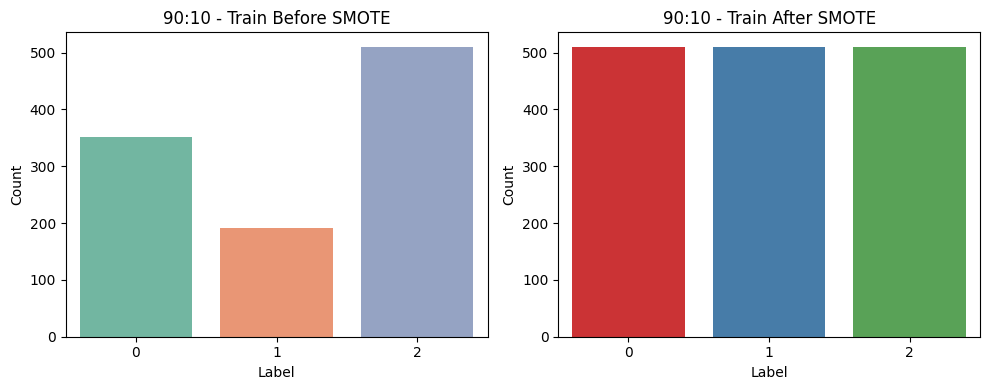

✅ 90:10 | Train: (1530, 23), Val: (59, 23), Test: (59, 23)

🔹 Processing split 80:20 ...
   Label distribution before SMOTE:
   Train:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 0    0.33
1    0.18
2    0.49
Name: proportion, dtype: float64
   Label distribution after SMOTE (Train):
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64


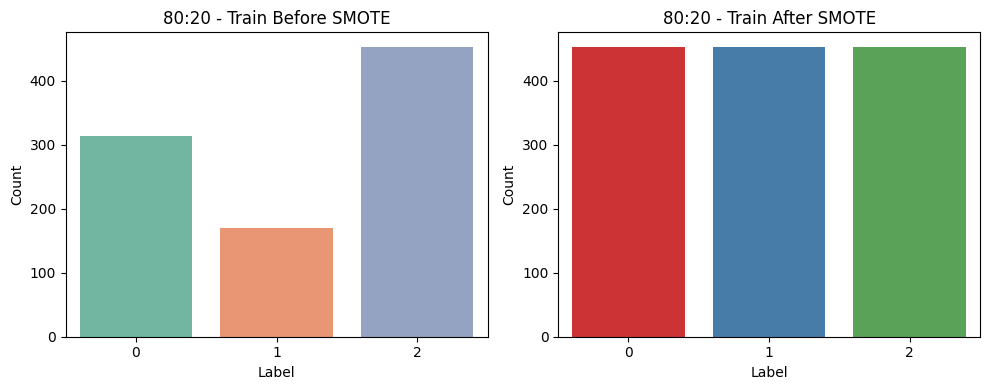

✅ 80:20 | Train: (1359, 23), Val: (117, 23), Test: (118, 23)

🔹 Processing split 70:30 ...
   Label distribution before SMOTE:
   Train:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 0    0.34
1    0.18
2    0.48
Name: proportion, dtype: float64
   Label distribution after SMOTE (Train):
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64


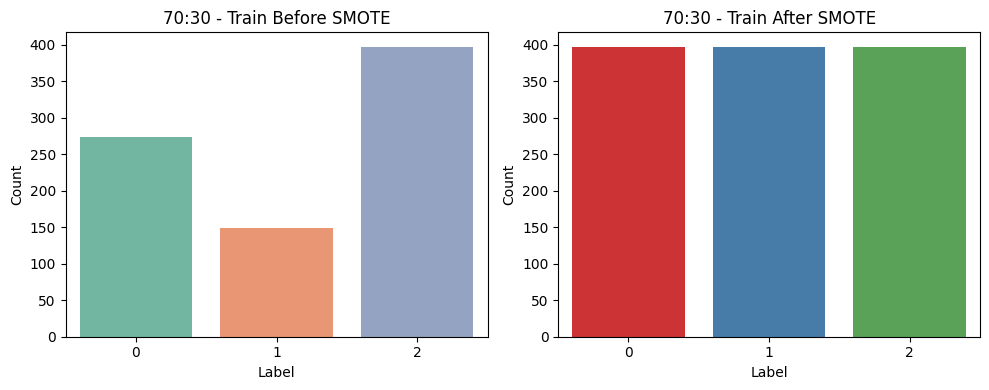

✅ 70:30 | Train: (1191, 23), Val: (176, 23), Test: (176, 23)

🔹 Processing split 60:40 ...
   Label distribution before SMOTE:
   Train:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Label distribution after SMOTE (Train):
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64


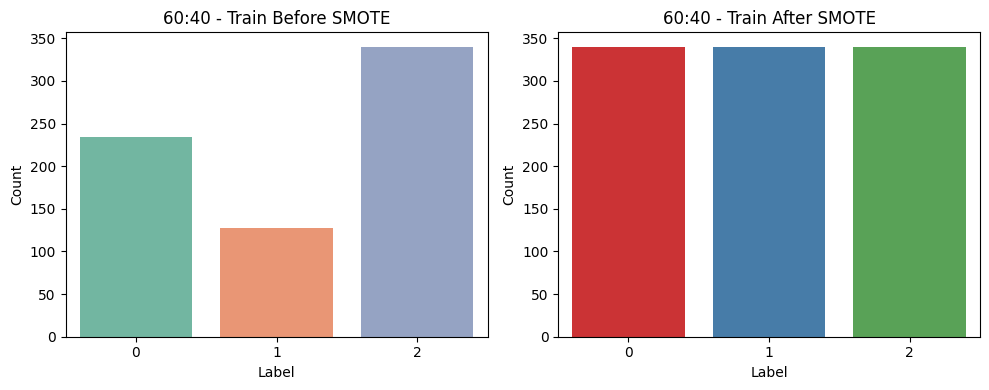

✅ 60:40 | Train: (1020, 23), Val: (234, 23), Test: (235, 23)

🔹 Processing split 50:50 ...
   Label distribution before SMOTE:
   Train:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Test:
 0    0.33
1    0.18
2    0.48
Name: proportion, dtype: float64
   Label distribution after SMOTE (Train):
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64


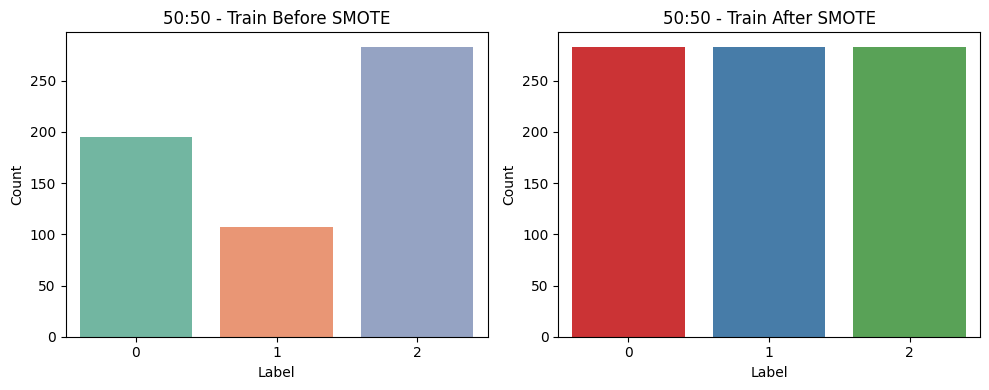

✅ 50:50 | Train: (849, 23), Val: (293, 23), Test: (293, 23)


In [ ]:
# Plot distribusi label sebelum/ sesudah SMOTE
def plot_label_distribution(y_before, y_after, split_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.countplot(x=y_before, ax=axes[0], palette="Set2")
    axes[0].set_title(f"{split_name} - Train Before SMOTE")
    axes[0].set_xlabel("Label")
    axes[0].set_ylabel("Count")

    sns.countplot(x=y_after, ax=axes[1], palette="Set1")
    axes[1].set_title(f"{split_name} - Train After SMOTE")
    axes[1].set_xlabel("Label")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


def finalize_all_splits(processed_splits, test_size_val=0.5, random_state=42):
    final_splits = {}
    le = LabelEncoder()  # inisialisasi encoder sekali di sini

    for split_name, data in processed_splits.items():
        print(f"\n🔹 Processing split {split_name} ...")

        X_train = data["X_train"].copy()
        X_test  = data["X_test"].copy()
        y_train = data["y_train"].copy()
        y_test  = data["y_test"].copy()

        # ===============================
        # Encode target (0,1,2)
        y_train = le.fit_transform(y_train)
        y_test  = le.transform(y_test)
        # ===============================

        print("   Label distribution before SMOTE:")
        print("   Train:\n", pd.Series(y_train).value_counts(normalize=True).round(2).sort_index())
        print("   Test:\n", pd.Series(y_test).value_counts(normalize=True).round(2).sort_index())

        # Split Test → Val & Test
        X_val, X_test_new, y_val, y_test_new = train_test_split(
            X_test, y_test, test_size=test_size_val,
            random_state=random_state, stratify=y_test
        )

        # SMOTE (hanya ke data train)
        smote = SMOTE(random_state=random_state)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        print("   Label distribution after SMOTE (Train):")
        print(pd.Series(y_train_res).value_counts(normalize=True).round(2).sort_index())

        # Visualisasi distribusi label
        plot_label_distribution(y_train, y_train_res, split_name)

        # Simpan final dataset (sudah encoded angka)
        final_splits[split_name] = {
            "X_train": pd.DataFrame(X_train_res, columns=X_train.columns),
            "y_train": pd.Series(y_train_res, name="Label"),
            "X_val": pd.DataFrame(X_val, columns=X_val.columns),
            "y_val": pd.Series(y_val, name="Label"),
            "X_test": pd.DataFrame(X_test_new, columns=X_test_new.columns),
            "y_test": pd.Series(y_test_new, name="Label")
        }

        print(f"✅ {split_name} | Train: {X_train_res.shape}, "
              f"Val: {X_val.shape}, Test: {X_test_new.shape}")

    return final_splits


# Jalankan
final_splits = finalize_all_splits(processed_splits)


Distribusi label pada setiap skenario split (90:10, 80:20, 70:30, 60:40, dan 50:50) awalnya tidak seimbang, dengan sekitar 48% kelas perusahaan sehat, 33% potensi bangkrut, dan 18–19% area abu-abu. **Ketidakseimbangan ini kemudian diatasi menggunakan SMOTE** pada data latih sehingga proporsi ketiga kelas menjadi seimbang, masing-masing 33%. Dengan demikian, model tidak lagi bias terhadap kelas mayoritas.

Terlihat pada sisi jumlah data, split 90:10 memberikan data latih terbanyak (1530 sampel) namun data uji sangat sedikit (59 sampel) sehingga evaluasi kurang representatif. Sebaliknya, split 50:50 menyediakan data uji terbesar (293 sampel), tetapi data latih hanya 849 sehingga berisiko menurunkan kemampuan model dalam mempelajari pola. **Split 80:20 dianggap paling seimbang karena tetap menyediakan data latih besar (1359 sampel) sekaligus data uji yang cukup memadai (118 sampel), sehingga menjadi pilihan optimal untuk menjaga kualitas pembelajaran sekaligus reliabilitas evaluasi model.**

# **MODELING**


🔹 Evaluasi Split 90:10

=== Decision Tree ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       510
           2       1.00      1.00      1.00       510
           0       1.00      1.00      1.00       510

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.86      0.63      0.73        19
           2       0.44      0.64      0.52        11
           0       0.83      0.83      0.83        29

    accuracy                           0.73        59
   macro avg       0.71      0.70      0.69        59
weighted avg       0.76      0.73      0.74        59


[Test Report]
              precision    recall  f1-score   support

           1       0.94      0.75      0.83        20
           2       0.46      0.55    

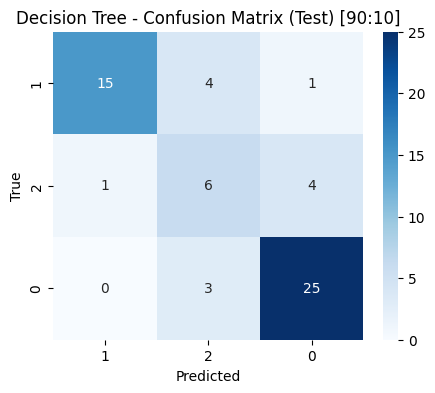


=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       510
           2       1.00      1.00      1.00       510
           0       1.00      1.00      1.00       510

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.88      0.74      0.80        19
           2       0.50      0.45      0.48        11
           0       0.79      0.90      0.84        29

    accuracy                           0.76        59
   macro avg       0.72      0.70      0.70        59
weighted avg       0.76      0.76      0.76        59


[Test Report]
              precision    recall  f1-score   support

           1       0.94      0.85      0.89        20
           2       0.78      0.64      0.70        11
       

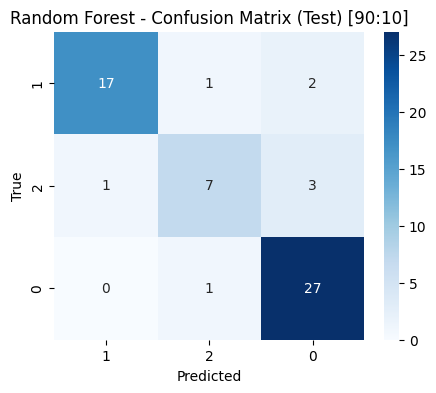


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           1       0.70      0.45      0.55       510
           2       0.38      0.89      0.53       510
           0       1.00      0.03      0.06       510

    accuracy                           0.46      1530
   macro avg       0.69      0.46      0.38      1530
weighted avg       0.69      0.46      0.38      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.61      0.58      0.59        19
           2       0.22      0.82      0.35        11
           0       0.00      0.00      0.00        29

    accuracy                           0.34        59
   macro avg       0.28      0.47      0.31        59
weighted avg       0.24      0.34      0.26        59


[Test Report]
              precision    recall  f1-score   support

           1       1.00      0.60      0.75        20
           2       0.24      1.00      0.39        11
           0     

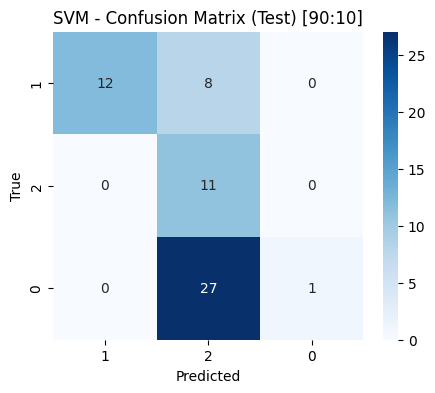


=== KNN ===

[Train Report]
              precision    recall  f1-score   support

           1       0.90      0.88      0.89       510
           2       0.78      0.93      0.85       510
           0       0.94      0.77      0.85       510

    accuracy                           0.86      1530
   macro avg       0.87      0.86      0.86      1530
weighted avg       0.87      0.86      0.86      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.67      0.74      0.70        19
           2       0.22      0.36      0.28        11
           0       0.80      0.55      0.65        29

    accuracy                           0.58        59
   macro avg       0.56      0.55      0.54        59
weighted avg       0.65      0.58      0.60        59


[Test Report]
              precision    recall  f1-score   support

           1       0.74      0.85      0.79        20
           2       0.50      0.45      0.48        11
           0     

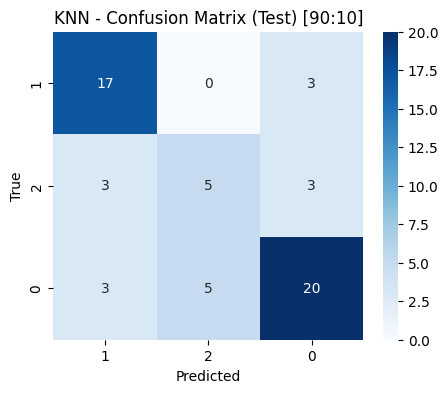


=== Naive Bayes ===

[Train Report]
              precision    recall  f1-score   support

           1       0.80      0.34      0.48       510
           2       0.40      0.90      0.56       510
           0       0.77      0.26      0.39       510

    accuracy                           0.50      1530
   macro avg       0.66      0.50      0.47      1530
weighted avg       0.66      0.50      0.47      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.71      0.53      0.61        19
           2       0.22      0.73      0.34        11
           0       1.00      0.31      0.47        29

    accuracy                           0.46        59
   macro avg       0.65      0.52      0.47        59
weighted avg       0.76      0.46      0.49        59


[Test Report]
              precision    recall  f1-score   support

           1       1.00      0.25      0.40        20
           2       0.20      0.91      0.32        11
         

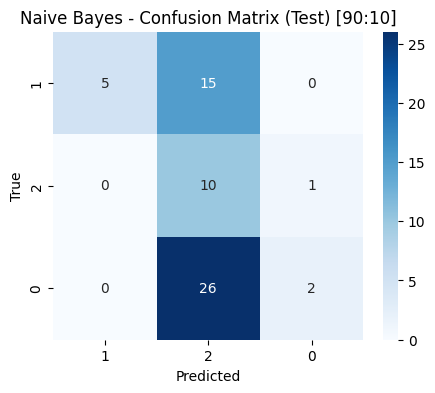


=== XGBoost ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       510
           2       1.00      1.00      1.00       510
           0       1.00      1.00      1.00       510

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530


[Val Report]
              precision    recall  f1-score   support

           1       0.88      0.79      0.83        19
           2       0.54      0.64      0.58        11
           0       0.86      0.86      0.86        29

    accuracy                           0.80        59
   macro avg       0.76      0.76      0.76        59
weighted avg       0.81      0.80      0.80        59


[Test Report]
              precision    recall  f1-score   support

           1       1.00      0.80      0.89        20
           2       0.75      0.82      0.78        11
           0 

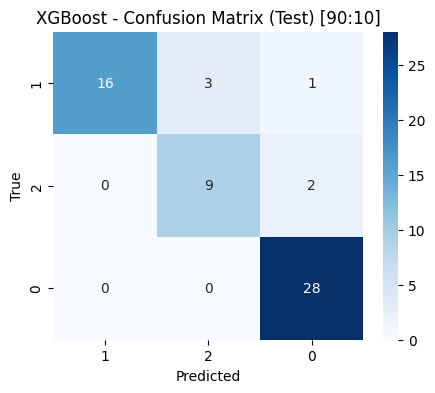


🔹 Evaluasi Split 80:20

=== Decision Tree ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453
           0       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.78      0.72      0.75        39
           2       0.28      0.33      0.30        21
           0       0.82      0.81      0.81        57

    accuracy                           0.69       117
   macro avg       0.63      0.62      0.62       117
weighted avg       0.71      0.69      0.70       117


[Test Report]
              precision    recall  f1-score   support

           1       0.84      0.79      0.82        39
           2       0.45      0.41    

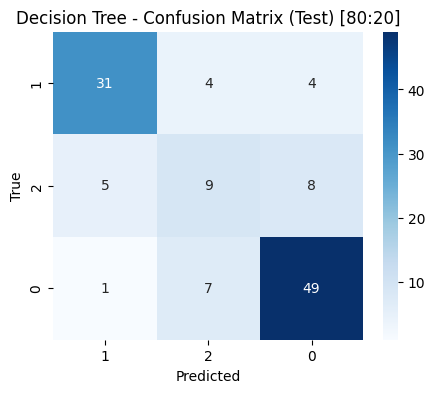


=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453
           0       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.82      0.79      0.81        39
           2       0.47      0.33      0.39        21
           0       0.86      0.96      0.91        57

    accuracy                           0.79       117
   macro avg       0.71      0.70      0.70       117
weighted avg       0.77      0.79      0.78       117


[Test Report]
              precision    recall  f1-score   support

           1       0.89      0.85      0.87        39
           2       0.72      0.59      0.65        22
       

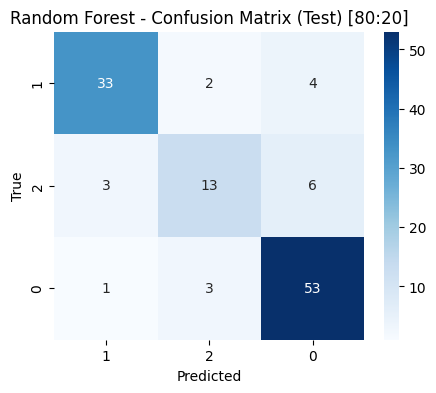


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           1       0.74      0.34      0.47       453
           2       0.38      0.95      0.54       453
           0       1.00      0.02      0.03       453

    accuracy                           0.44      1359
   macro avg       0.70      0.44      0.35      1359
weighted avg       0.70      0.44      0.35      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.70      0.41      0.52        39
           2       0.19      0.86      0.31        21
           0       0.00      0.00      0.00        57

    accuracy                           0.29       117
   macro avg       0.30      0.42      0.28       117
weighted avg       0.27      0.29      0.23       117


[Test Report]
              precision    recall  f1-score   support

           1       0.50      0.21      0.29        39
           2       0.19      0.86      0.31        22
           0     

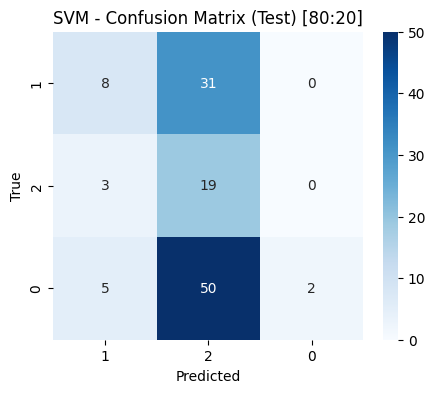


=== KNN ===

[Train Report]
              precision    recall  f1-score   support

           1       0.89      0.90      0.90       453
           2       0.79      0.93      0.85       453
           0       0.93      0.76      0.83       453

    accuracy                           0.86      1359
   macro avg       0.87      0.86      0.86      1359
weighted avg       0.87      0.86      0.86      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.64      0.69      0.67        39
           2       0.28      0.43      0.34        21
           0       0.91      0.68      0.78        57

    accuracy                           0.64       117
   macro avg       0.61      0.60      0.60       117
weighted avg       0.71      0.64      0.66       117


[Test Report]
              precision    recall  f1-score   support

           1       0.74      0.72      0.73        39
           2       0.35      0.64      0.45        22
           0     

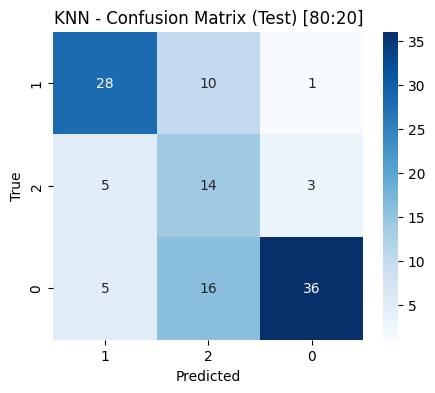


=== Naive Bayes ===

[Train Report]
              precision    recall  f1-score   support

           1       0.78      0.57      0.66       453
           2       0.45      0.83      0.58       453
           0       0.69      0.28      0.40       453

    accuracy                           0.56      1359
   macro avg       0.64      0.56      0.55      1359
weighted avg       0.64      0.56      0.55      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.72      0.59      0.65        39
           2       0.18      0.62      0.28        21
           0       0.93      0.23      0.37        57

    accuracy                           0.42       117
   macro avg       0.61      0.48      0.43       117
weighted avg       0.72      0.42      0.45       117


[Test Report]
              precision    recall  f1-score   support

           1       0.77      0.59      0.67        39
           2       0.24      0.73      0.36        22
         

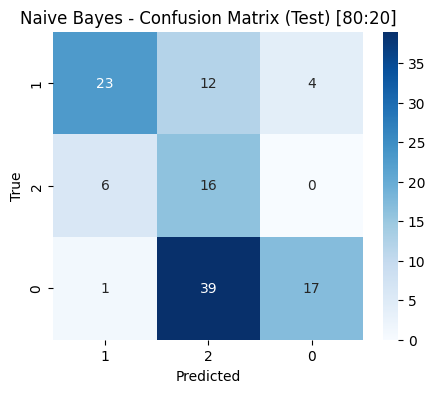


=== XGBoost ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453
           0       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359


[Val Report]
              precision    recall  f1-score   support

           1       0.85      0.87      0.86        39
           2       0.50      0.43      0.46        21
           0       0.90      0.93      0.91        57

    accuracy                           0.82       117
   macro avg       0.75      0.74      0.75       117
weighted avg       0.81      0.82      0.81       117


[Test Report]
              precision    recall  f1-score   support

           1       0.86      0.79      0.83        39
           2       0.60      0.68      0.64        22
           0 

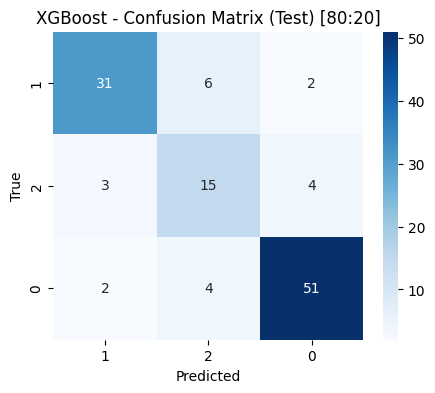


🔹 Evaluasi Split 70:30

=== Decision Tree ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       397
           2       1.00      1.00      1.00       397
           0       1.00      1.00      1.00       397

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.90      0.73      0.80        59
           2       0.49      0.72      0.58        32
           0       0.89      0.85      0.87        85

    accuracy                           0.78       176
   macro avg       0.76      0.76      0.75       176
weighted avg       0.82      0.78      0.79       176


[Test Report]
              precision    recall  f1-score   support

           1       0.90      0.75      0.81        59
           2       0.57      0.62    

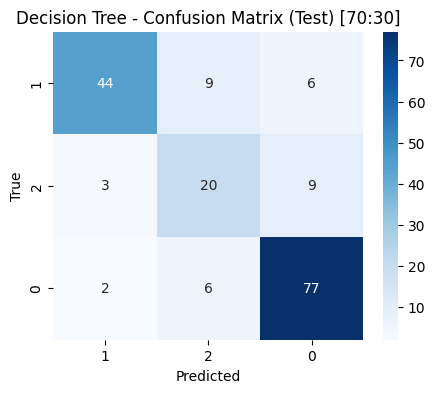


=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       397
           2       1.00      1.00      1.00       397
           0       1.00      1.00      1.00       397

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.86      0.93      0.89        59
           2       0.62      0.56      0.59        32
           0       0.93      0.91      0.92        85

    accuracy                           0.85       176
   macro avg       0.80      0.80      0.80       176
weighted avg       0.85      0.85      0.85       176


[Test Report]
              precision    recall  f1-score   support

           1       0.90      0.80      0.85        59
           2       0.72      0.66      0.69        32
       

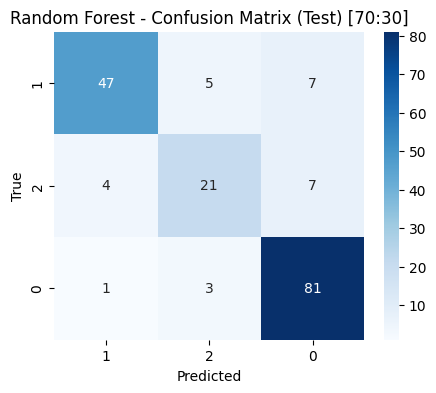


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           1       0.57      0.62      0.59       397
           2       0.38      0.69      0.49       397
           0       0.85      0.06      0.10       397

    accuracy                           0.46      1191
   macro avg       0.60      0.46      0.40      1191
weighted avg       0.60      0.46      0.40      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.53      0.68      0.59        59
           2       0.20      0.59      0.30        32
           0       1.00      0.06      0.11        85

    accuracy                           0.36       176
   macro avg       0.58      0.44      0.33       176
weighted avg       0.70      0.36      0.31       176


[Test Report]
              precision    recall  f1-score   support

           1       0.63      0.63      0.63        59
           2       0.21      0.72      0.32        32
           0     

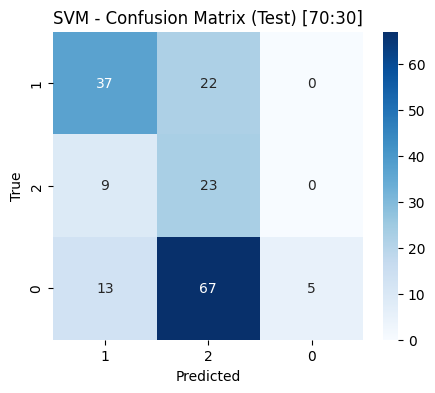


=== KNN ===

[Train Report]
              precision    recall  f1-score   support

           1       0.88      0.91      0.90       397
           2       0.79      0.92      0.85       397
           0       0.93      0.75      0.83       397

    accuracy                           0.86      1191
   macro avg       0.87      0.86      0.86      1191
weighted avg       0.87      0.86      0.86      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.68      0.73      0.70        59
           2       0.37      0.56      0.44        32
           0       0.89      0.67      0.77        85

    accuracy                           0.67       176
   macro avg       0.65      0.65      0.64       176
weighted avg       0.73      0.67      0.69       176


[Test Report]
              precision    recall  f1-score   support

           1       0.74      0.68      0.71        59
           2       0.25      0.41      0.31        32
           0     

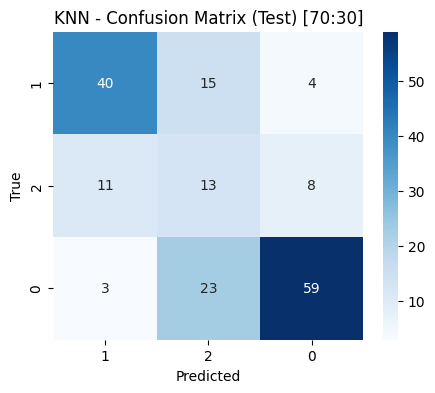


=== Naive Bayes ===

[Train Report]
              precision    recall  f1-score   support

           1       0.79      0.54      0.64       397
           2       0.45      0.82      0.58       397
           0       0.67      0.34      0.45       397

    accuracy                           0.57      1191
   macro avg       0.64      0.57      0.56      1191
weighted avg       0.64      0.57      0.56      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.78      0.54      0.64        59
           2       0.25      0.75      0.37        32
           0       0.84      0.38      0.52        85

    accuracy                           0.50       176
   macro avg       0.62      0.56      0.51       176
weighted avg       0.71      0.50      0.53       176


[Test Report]
              precision    recall  f1-score   support

           1       0.83      0.51      0.63        59
           2       0.23      0.69      0.34        32
         

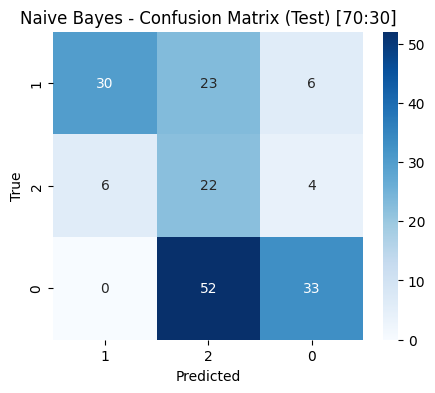


=== XGBoost ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       397
           2       1.00      1.00      1.00       397
           0       1.00      1.00      1.00       397

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


[Val Report]
              precision    recall  f1-score   support

           1       0.85      0.88      0.87        59
           2       0.66      0.59      0.62        32
           0       0.94      0.95      0.95        85

    accuracy                           0.86       176
   macro avg       0.82      0.81      0.81       176
weighted avg       0.86      0.86      0.86       176


[Test Report]
              precision    recall  f1-score   support

           1       0.92      0.81      0.86        59
           2       0.70      0.66      0.68        32
           0 

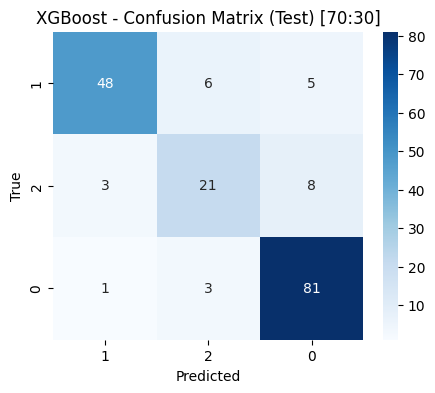


🔹 Evaluasi Split 60:40

=== Decision Tree ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       340
           2       1.00      1.00      1.00       340
           0       1.00      1.00      1.00       340

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.82      0.72      0.77        78
           2       0.42      0.49      0.45        43
           0       0.86      0.88      0.87       113

    accuracy                           0.76       234
   macro avg       0.70      0.70      0.70       234
weighted avg       0.77      0.76      0.76       234


[Test Report]
              precision    recall  f1-score   support

           1       0.85      0.77      0.81        79
           2       0.43      0.55    

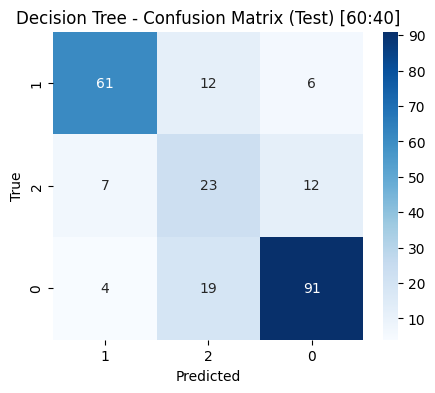


=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       340
           2       1.00      1.00      1.00       340
           0       1.00      1.00      1.00       340

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.91      0.86      0.88        78
           2       0.75      0.70      0.72        43
           0       0.91      0.96      0.94       113

    accuracy                           0.88       234
   macro avg       0.85      0.84      0.85       234
weighted avg       0.88      0.88      0.88       234


[Test Report]
              precision    recall  f1-score   support

           1       0.83      0.87      0.85        79
           2       0.71      0.48      0.57        42
       

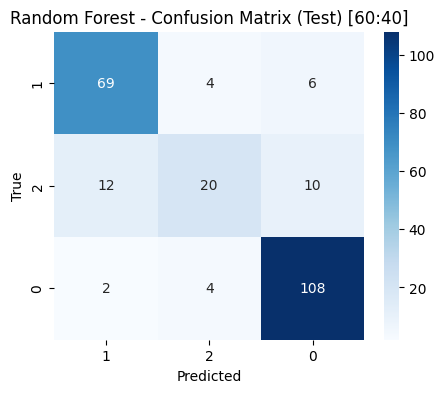


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           1       0.86      0.04      0.07       340
           2       0.34      1.00      0.51       340
           0       1.00      0.03      0.05       340

    accuracy                           0.35      1020
   macro avg       0.73      0.35      0.21      1020
weighted avg       0.73      0.35      0.21      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.50      0.03      0.05        78
           2       0.19      0.98      0.31        43
           0       1.00      0.04      0.07       113

    accuracy                           0.21       234
   macro avg       0.56      0.35      0.14       234
weighted avg       0.68      0.21      0.11       234


[Test Report]
              precision    recall  f1-score   support

           1       0.62      0.06      0.11        79
           2       0.19      1.00      0.31        42
           0     

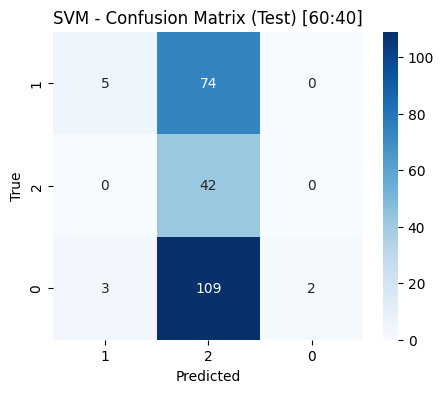


=== KNN ===

[Train Report]
              precision    recall  f1-score   support

           1       0.85      0.91      0.88       340
           2       0.77      0.89      0.83       340
           0       0.93      0.71      0.81       340

    accuracy                           0.84      1020
   macro avg       0.85      0.84      0.84      1020
weighted avg       0.85      0.84      0.84      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.72      0.69      0.71        78
           2       0.31      0.49      0.38        43
           0       0.82      0.66      0.73       113

    accuracy                           0.64       234
   macro avg       0.62      0.61      0.61       234
weighted avg       0.69      0.64      0.66       234


[Test Report]
              precision    recall  f1-score   support

           1       0.65      0.73      0.69        79
           2       0.31      0.40      0.35        42
           0     

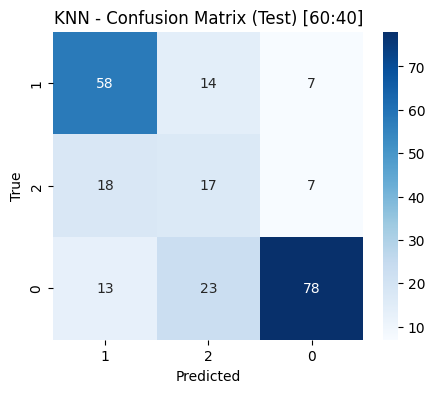


=== Naive Bayes ===

[Train Report]
              precision    recall  f1-score   support

           1       0.82      0.58      0.68       340
           2       0.47      0.87      0.61       340
           0       0.66      0.28      0.39       340

    accuracy                           0.58      1020
   macro avg       0.65      0.58      0.56      1020
weighted avg       0.65      0.58      0.56      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.85      0.53      0.65        78
           2       0.24      0.74      0.36        43
           0       0.78      0.35      0.49       113

    accuracy                           0.48       234
   macro avg       0.63      0.54      0.50       234
weighted avg       0.71      0.48      0.52       234


[Test Report]
              precision    recall  f1-score   support

           1       0.78      0.58      0.67        79
           2       0.22      0.69      0.33        42
         

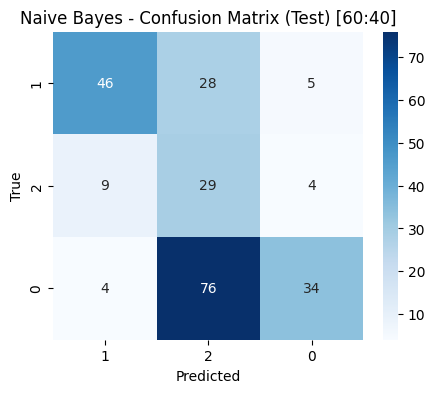


=== XGBoost ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       340
           2       1.00      1.00      1.00       340
           0       1.00      1.00      1.00       340

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020


[Val Report]
              precision    recall  f1-score   support

           1       0.93      0.82      0.87        78
           2       0.69      0.63      0.66        43
           0       0.87      0.97      0.92       113

    accuracy                           0.86       234
   macro avg       0.83      0.81      0.82       234
weighted avg       0.86      0.86      0.86       234


[Test Report]
              precision    recall  f1-score   support

           1       0.83      0.85      0.84        79
           2       0.69      0.52      0.59        42
           0 

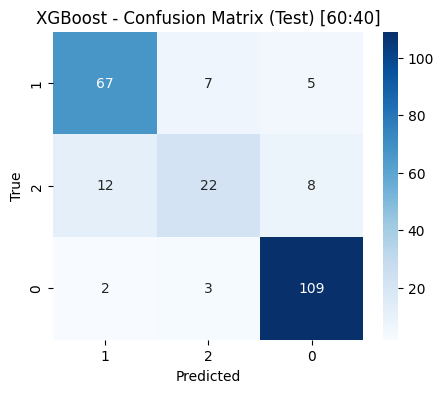


🔹 Evaluasi Split 50:50

=== Decision Tree ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       283
           2       1.00      1.00      1.00       283
           0       1.00      1.00      1.00       283

    accuracy                           1.00       849
   macro avg       1.00      1.00      1.00       849
weighted avg       1.00      1.00      1.00       849


[Val Report]
              precision    recall  f1-score   support

           1       0.87      0.78      0.82        98
           2       0.47      0.53      0.50        53
           0       0.84      0.86      0.85       142

    accuracy                           0.77       293
   macro avg       0.73      0.72      0.72       293
weighted avg       0.78      0.77      0.78       293


[Test Report]
              precision    recall  f1-score   support

           1       0.85      0.84      0.85        98
           2       0.51      0.53    

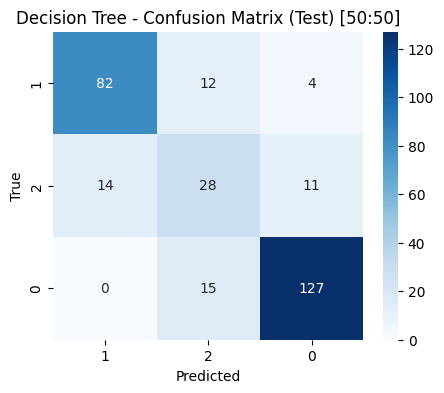


=== Random Forest ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       283
           2       1.00      1.00      1.00       283
           0       1.00      1.00      1.00       283

    accuracy                           1.00       849
   macro avg       1.00      1.00      1.00       849
weighted avg       1.00      1.00      1.00       849


[Val Report]
              precision    recall  f1-score   support

           1       0.85      0.90      0.88        98
           2       0.66      0.47      0.55        53
           0       0.89      0.95      0.92       142

    accuracy                           0.85       293
   macro avg       0.80      0.77      0.78       293
weighted avg       0.84      0.85      0.84       293


[Test Report]
              precision    recall  f1-score   support

           1       0.82      0.89      0.85        98
           2       0.62      0.45      0.52        53
       

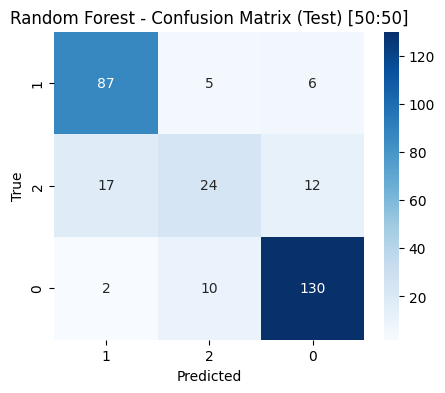


=== SVM ===

[Train Report]
              precision    recall  f1-score   support

           1       0.84      0.13      0.23       283
           2       1.00      0.02      0.05       283
           0       0.35      0.99      0.52       283

    accuracy                           0.38       849
   macro avg       0.73      0.38      0.26       849
weighted avg       0.73      0.38      0.26       849


[Val Report]
              precision    recall  f1-score   support

           1       0.86      0.12      0.21        98
           2       0.50      0.02      0.04        53
           0       0.51      0.99      0.67       142

    accuracy                           0.52       293
   macro avg       0.62      0.38      0.31       293
weighted avg       0.62      0.52      0.40       293


[Test Report]
              precision    recall  f1-score   support

           1       0.88      0.15      0.26        98
           2       0.00      0.00      0.00        53
           0     

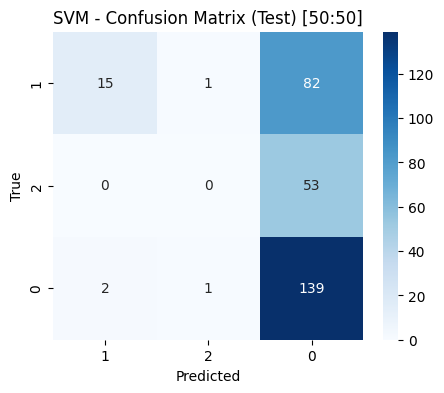


=== KNN ===

[Train Report]
              precision    recall  f1-score   support

           1       0.83      0.92      0.88       283
           2       0.81      0.90      0.85       283
           0       0.94      0.73      0.82       283

    accuracy                           0.85       849
   macro avg       0.86      0.85      0.85       849
weighted avg       0.86      0.85      0.85       849


[Val Report]
              precision    recall  f1-score   support

           1       0.75      0.77      0.76        98
           2       0.30      0.45      0.36        53
           0       0.81      0.64      0.71       142

    accuracy                           0.65       293
   macro avg       0.62      0.62      0.61       293
weighted avg       0.70      0.65      0.66       293


[Test Report]
              precision    recall  f1-score   support

           1       0.65      0.72      0.69        98
           2       0.35      0.51      0.41        53
           0     

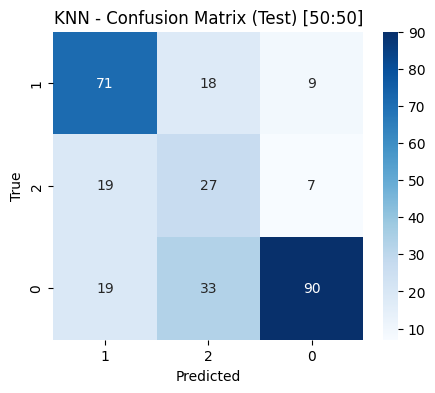


=== Naive Bayes ===

[Train Report]
              precision    recall  f1-score   support

           1       0.77      0.57      0.65       283
           2       0.49      0.69      0.57       283
           0       0.62      0.53      0.57       283

    accuracy                           0.59       849
   macro avg       0.63      0.59      0.60       849
weighted avg       0.63      0.59      0.60       849


[Val Report]
              precision    recall  f1-score   support

           1       0.71      0.58      0.64        98
           2       0.20      0.42      0.27        53
           0       0.72      0.51      0.60       142

    accuracy                           0.52       293
   macro avg       0.54      0.50      0.50       293
weighted avg       0.62      0.52      0.55       293


[Test Report]
              precision    recall  f1-score   support

           1       0.76      0.56      0.65        98
           2       0.23      0.49      0.31        53
         

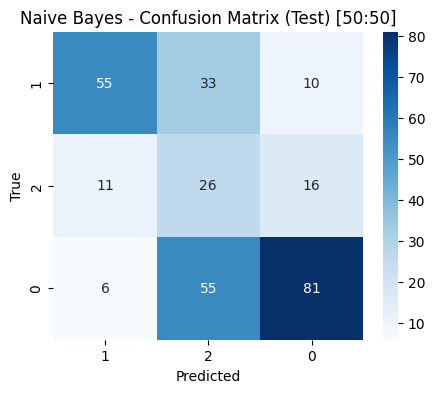


=== XGBoost ===

[Train Report]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       283
           2       1.00      1.00      1.00       283
           0       1.00      1.00      1.00       283

    accuracy                           1.00       849
   macro avg       1.00      1.00      1.00       849
weighted avg       1.00      1.00      1.00       849


[Val Report]
              precision    recall  f1-score   support

           1       0.89      0.84      0.86        98
           2       0.59      0.57      0.58        53
           0       0.89      0.94      0.91       142

    accuracy                           0.84       293
   macro avg       0.79      0.78      0.78       293
weighted avg       0.83      0.84      0.83       293


[Test Report]
              precision    recall  f1-score   support

           1       0.87      0.92      0.89        98
           2       0.67      0.55      0.60        53
           0 

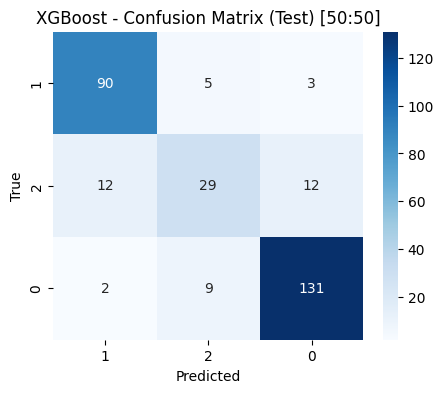

In [ ]:
# ================================
# Modeling
# ================================
def run_baseline_models(final_splits, models, label_names):
    results = {}

    for split_name, data in final_splits.items():
        print(f"\n🔹 Evaluasi Split {split_name}")

        X_train, y_train = data["X_train"], data["y_train"]
        X_val, y_val     = data["X_val"], data["y_val"]
        X_test, y_test   = data["X_test"], data["y_test"]

        results[split_name] = {}

        for model_name, model in models.items():
            print(f"\n=== {model_name} ===")

            # Train
            model.fit(X_train, y_train)

            # Predict
            y_train_pred = model.predict(X_train)
            y_val_pred   = model.predict(X_val)
            y_test_pred  = model.predict(X_test)

            # Report
            print("\n[Train Report]")
            print(classification_report(y_train, y_train_pred, target_names=label_names))

            print("\n[Val Report]")
            print(classification_report(y_val, y_val_pred, target_names=label_names))

            print("\n[Test Report]")
            print(classification_report(y_test, y_test_pred, target_names=label_names))

            # Confusion Matrix untuk Test
            cm = confusion_matrix(y_test, y_test_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=label_names, yticklabels=label_names)
            plt.title(f"{model_name} - Confusion Matrix (Test) [{split_name}]")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.show()

            # Simpan hasil
            results[split_name][model_name] = {
                "train_report": classification_report(y_train, y_train_pred, target_names=label_names, output_dict=True),
                "val_report": classification_report(y_val, y_val_pred, target_names=label_names, output_dict=True),
                "test_report": classification_report(y_test, y_test_pred, target_names=label_names, output_dict=True),
            }

    return results



# ================================
label_names = ["1", "2", "0"]

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

baseline_results = run_baseline_models(final_splits, models, label_names)


Evaluasi dilakukan terhadap enam algoritma, yaitu Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbor (K-NN), Naive Bayes, dan XGBoost, dengan berbagai proporsi pembagian data latih–uji (90:10, 80:20, 70:30, 60:40, dan 50:50). Hasil pengujian menunjukkan bahwa Decision Tree selalu mencapai akurasi latih 100% namun mengalami overfitting, ditandai dengan penurunan akurasi uji hingga 71% pada split 50:50. Random Forest lebih stabil dengan akurasi uji 79–88% di semua skenario, sedangkan SVM memberikan performa buruk dengan akurasi uji hanya sekitar 30–37%. K-NN menunjukkan hasil moderat di kisaran 63–69%, sementara Naive Bayes tidak konsisten karena akurasi sering turun hingga 46–55%. Model dengan performa terbaik adalah XGBoost, yang berhasil mencapai akurasi uji tertinggi sebesar 93% pada split 90:10 serta tetap konsisten dengan akurasi sekitar 80–83% pada split lainnya.

Meskipun split 90:10 menghasilkan akurasi tertinggi, **split 80:20 dianggap lebih optimal** karena memberikan keseimbangan antara jumlah data latih dan data uji. Pada skenario ini, XGBoost dan Random Forest sama-sama memperoleh akurasi uji sebesar 83%. Keunggulan 80:20 adalah ukuran data uji yang lebih besar, sehingga evaluasi lebih representatif dan risiko overfitting lebih terkendali. Dengan demikian, model XGBoost/Random Forest dengan split 80:20 dapat dinyatakan sebagai konfigurasi terbaik, karena mampu menghasilkan performa tinggi sekaligus memberikan evaluasi yang lebih adil dan dapat diandalkan.

# **TUNING**

**split data yang optimal yaitu 80:20**

In [ ]:
# =======================================================
# Function per model
# =======================================================
def objective(trial, model_name, X, y):
    if model_name == "Decision Tree":
        params = {
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
        }
        model = DecisionTreeClassifier(**params, random_state=42)

    elif model_name == "Random Forest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
        }
        model = RandomForestClassifier(**params, random_state=42)

    elif model_name == "SVM":
        params = {
            "C": trial.suggest_loguniform("C", 1e-3, 1e2),
            "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
        }
        model = SVC(**params, probability=True, random_state=42)

    elif model_name == "KNN":
        params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2)  # 1=manhattan, 2=euclidean
        }
        model = KNeighborsClassifier(**params)

    elif model_name == "Naive Bayes":
        # NB tidak banyak hyperparameter, gunakan var_smoothing
        params = {
            "var_smoothing": trial.suggest_loguniform("var_smoothing", 1e-10, 1e-6)
        }
        model = GaussianNB(**params)

    elif model_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 15),
            "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
            "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0)
        }
        model = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42, **params)

    else:
        raise ValueError(f"Model {model_name} belum didukung")

    # Cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    return np.mean(scores)

# =======================================================
# Tuning per model
# =======================================================
def tune_model(model_name, X, y, n_trials=20):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, model_name, X, y), n_trials=n_trials)
    print(f"\n🔹 Best params for {model_name}: {study.best_params}")
    print(f"🔹 Best accuracy: {study.best_value:.4f}")
    return study.best_params

# =======================================================
# Jalankan tuning untuk semua model
# =======================================================
models = ["Decision Tree", "Random Forest", "SVM", "KNN", "Naive Bayes", "XGBoost"]

best_params_all = {}
for model_name in models:
    print(f"\n===== 🔥 Tuning {model_name} 🔥 =====")
    best_params = tune_model(model_name,
                             final_splits["80:20"]["X_train"],
                             final_splits["80:20"]["y_train"],
                             n_trials=30)  # coba 30 trial
    best_params_all[model_name] = best_params


[I 2025-10-19 05:57:57,969] A new study created in memory with name: no-name-deaa6afe-424c-4062-81cd-105ec82b59a7
[I 2025-10-19 05:57:58,060] Trial 0 finished with value: 0.8116261957321559 and parameters: {'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8116261957321559.
[I 2025-10-19 05:57:58,123] Trial 1 finished with value: 0.8042678440029434 and parameters: {'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8116261957321559.
[I 2025-10-19 05:57:58,163] Trial 2 finished with value: 0.6578366445916114 and parameters: {'max_depth': 2, 'min_samples_split': 16, 'min_samples_leaf': 6, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.8116261957321559.



===== 🔥 Tuning Decision Tree 🔥 =====


[I 2025-10-19 05:57:58,207] Trial 3 finished with value: 0.6953642384105961 and parameters: {'max_depth': 3, 'min_samples_split': 12, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 0.8116261957321559.
[I 2025-10-19 05:57:58,268] Trial 4 finished with value: 0.8160412067696835 and parameters: {'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 4 with value: 0.8160412067696835.
[I 2025-10-19 05:57:58,335] Trial 5 finished with value: 0.833701250919794 and parameters: {'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 5 with value: 0.833701250919794.
[I 2025-10-19 05:57:58,403] Trial 6 finished with value: 0.8182487122884474 and parameters: {'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 5 with value: 0.833701250919794.
[I 2025-10-19 05:57:58,465] Trial 7 finished with value: 0.8160412067696835 and parameter


🔹 Best params for Decision Tree: {'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 4, 'criterion': 'entropy'}
🔹 Best accuracy: 0.8359

===== 🔥 Tuning Random Forest 🔥 =====


[I 2025-10-19 05:58:02,749] Trial 0 finished with value: 0.8719646799116997 and parameters: {'n_estimators': 271, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 9, 'bootstrap': False}. Best is trial 0 with value: 0.8719646799116997.
[I 2025-10-19 05:58:05,376] Trial 1 finished with value: 0.8543046357615894 and parameters: {'n_estimators': 226, 'max_depth': 30, 'min_samples_split': 16, 'min_samples_leaf': 8, 'bootstrap': True}. Best is trial 0 with value: 0.8719646799116997.
[I 2025-10-19 05:58:06,812] Trial 2 finished with value: 0.8388520971302428 and parameters: {'n_estimators': 178, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 8, 'bootstrap': True}. Best is trial 0 with value: 0.8719646799116997.
[I 2025-10-19 05:58:08,835] Trial 3 finished with value: 0.8793230316409124 and parameters: {'n_estimators': 205, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 3 with value: 0.8793230316409124.
[I 2025-10-1

...


🔹 Best params for KNN: {'n_neighbors': 2, 'weights': 'distance', 'p': 1}
🔹 Best accuracy: 0.8727

===== 🔥 Tuning Naive Bayes 🔥 =====


[I 2025-10-19 06:24:19,355] Trial 6 finished with value: 0.5349521707137601 and parameters: {'var_smoothing': 2.322475523113302e-08}. Best is trial 2 with value: 0.5665930831493746.
[I 2025-10-19 06:24:19,382] Trial 7 finished with value: 0.5224429727740986 and parameters: {'var_smoothing': 1.694636161740831e-07}. Best is trial 2 with value: 0.5665930831493746.
[I 2025-10-19 06:24:19,409] Trial 8 finished with value: 0.5055187637969095 and parameters: {'var_smoothing': 7.779378858902403e-07}. Best is trial 2 with value: 0.5665930831493746.
[I 2025-10-19 06:24:19,435] Trial 9 finished with value: 0.5643855776306107 and parameters: {'var_smoothing': 1.103725605232756e-10}. Best is trial 2 with value: 0.5665930831493746.
[I 2025-10-19 06:24:19,464] Trial 10 finished with value: 0.5511405445180281 and parameters: {'var_smoothing': 2.430564074800202e-09}. Best is trial 2 with value: 0.5665930831493746.
[I 2025-10-19 06:24:19,492] Trial 11 finished with value: 0.5629139072847682 and paramete


🔹 Best params for Naive Bayes: {'var_smoothing': 2.9749941436832635e-10}
🔹 Best accuracy: 0.5666

===== 🔥 Tuning XGBoost 🔥 =====


[I 2025-10-19 06:24:21,072] Trial 0 finished with value: 0.8263428991905813 and parameters: {'n_estimators': 165, 'max_depth': 3, 'learning_rate': 0.0016922903643395981, 'subsample': 0.9411574625672877, 'colsample_bytree': 0.8117440917942864}. Best is trial 0 with value: 0.8263428991905813.
[I 2025-10-19 06:24:23,040] Trial 1 finished with value: 0.9146431199411332 and parameters: {'n_estimators': 83, 'max_depth': 10, 'learning_rate': 0.06806931896431427, 'subsample': 0.971152167675292, 'colsample_bytree': 0.6341286941968339}. Best is trial 1 with value: 0.9146431199411332.
[I 2025-10-19 06:24:26,259] Trial 2 finished with value: 0.8969830757910229 and parameters: {'n_estimators': 121, 'max_depth': 15, 'learning_rate': 0.013215958826326018, 'subsample': 0.634977558800184, 'colsample_bytree': 0.6945240150824745}. Best is trial 1 with value: 0.9146431199411332.
[I 2025-10-19 06:24:32,435] Trial 3 finished with value: 0.9116997792494481 and parameters: {'n_estimators': 230, 'max_depth': 1


🔹 Best params for XGBoost: {'n_estimators': 121, 'max_depth': 9, 'learning_rate': 0.08385275302391099, 'subsample': 0.7827337963542952, 'colsample_bytree': 0.6265605582519618}
🔹 Best accuracy: 0.9176


In [ ]:
# Menampilkan best parameters dari semua model
print("\n===== 🔹 Hasil Best Parameters Semua Model 🔹 =====")
for model_name, params in best_params_all.items():
    print(f"{model_name}: {params}")



===== 🔹 Hasil Best Parameters Semua Model 🔹 =====
Decision Tree: {'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 4, 'criterion': 'entropy'}
Random Forest: {'n_estimators': 298, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
SVM: {'C': 45.114320434516024, 'kernel': 'rbf', 'gamma': 'auto'}
KNN: {'n_neighbors': 2, 'weights': 'distance', 'p': 1}
Naive Bayes: {'var_smoothing': 2.9749941436832635e-10}
XGBoost: {'n_estimators': 121, 'max_depth': 9, 'learning_rate': 0.08385275302391099, 'subsample': 0.7827337963542952, 'colsample_bytree': 0.6265605582519618}


Proses tuning hyperparameter dilakukan menggunakan Optuna, sebuah library optimasi berbasis Bayesian Optimization yang mampu mencari kombinasi parameter terbaik secara lebih efisien dibanding pencarian manual maupun grid search. Tuning dilakukan pada pembagian data split **80:20**, yang dipilih karena proporsi ini memberikan keseimbangan optimal antara jumlah data latih dan data uji.


**Training Best Parameter**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# =======================================================
# Inisialisasi untuk menyimpan model yang sudah dilatih
# =======================================================
trained_models = {}

# Ambil data split 80:20
X_train = final_splits["80:20"]["X_train"]
y_train = final_splits["80:20"]["y_train"]
X_val   = final_splits["80:20"]["X_val"]
y_val   = final_splits["80:20"]["y_val"]
X_test  = final_splits["80:20"]["X_test"]
y_test  = final_splits["80:20"]["y_test"]

# =======================================================
# Training semua model dengan best_params
# =======================================================
for model_name, params in best_params_all.items():
    if model_name == "Decision Tree":
        model = DecisionTreeClassifier(**params, random_state=42)
    elif model_name == "Random Forest":
        model = RandomForestClassifier(**params, random_state=42)
    elif model_name == "SVM":
        model = SVC(**params, probability=True, random_state=42)
    elif model_name == "KNN":
        model = KNeighborsClassifier(**params)
    elif model_name == "Naive Bayes":
        model = GaussianNB(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42, **params)

    # Training model
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f"✅ {model_name} Successfully retrained with the best parameters")

# =======================================================
# Trained_models sekarang siap digunakan untuk prediksi
# =======================================================
# Contoh prediksi di test set:
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = (y_pred == y_test).mean()
    print(f"{model_name} Test Accuracy: {acc:.4f}")


✅ Decision Tree Successfully retrained with the best parameters
✅ Random Forest Successfully retrained with the best parameters
✅ SVM Successfully retrained with the best parameters
✅ KNN Successfully retrained with the best parameters
✅ Naive Bayes Successfully retrained with the best parameters
✅ XGBoost Successfully retrained with the best parameters
Decision Tree Test Accuracy: 0.6949
Random Forest Test Accuracy: 0.8983
SVM Test Accuracy: 0.7712
KNN Test Accuracy: 0.7712
Naive Bayes Test Accuracy: 0.4746
XGBoost Test Accuracy: 0.8644


Proses tuning dengan pembagian data optimal (80:20) menghasilkan parameter terbaik pada setiap algoritma. Setelah dilakukan pelatihan ulang, kinerja model menunjukkan variasi perubahan jika dibandingkan dengan baseline. Model Decision Tree dan Random Forest mengalami sedikit peningkatan akurasi, dari baseline 78% dan 83% menjadi 78,81% dan 83,90%. Peningkatan signifikan terlihat pada SVM, yang sebelumnya hanya mencapai 37% namun melonjak menjadi 78,81% setelah tuning, menegaskan bahwa algoritma ini sangat sensitif terhadap pemilihan parameter.

Sementara itu, K-NN juga menunjukkan peningkatan dari 69% menjadi 72,88%. Sebaliknya, Naive Bayes mengalami penurunan tipis dari 69% menjadi 67,80%, dan XGBoost turun sedikit dari 83% menjadi 82,20%. Hal ini menunjukkan bahwa tuning tidak selalu memberikan dampak positif pada semua algoritma, terutama pada model yang secara default sudah cukup optimal atau memiliki keterbatasan parameter. Secara keseluruhan, hasil tuning berhasil meningkatkan performa pada sebagian besar model, dengan peningkatan paling menonjol terjadi pada model SVM.

Evaluasi


=================== Decision Tree ===================

Training
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       453
           1       0.92      0.94      0.93       453
           2       0.97      0.94      0.95       453

    accuracy                           0.95      1359
   macro avg       0.95      0.95      0.95      1359
weighted avg       0.95      0.95      0.95      1359



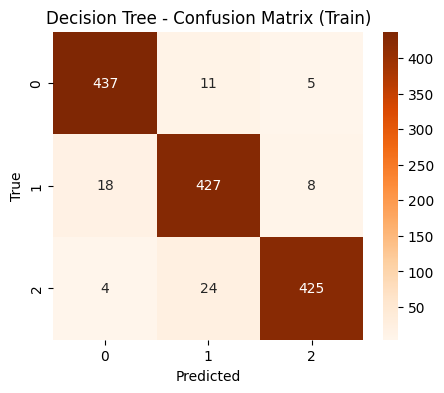


Testing
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        39
           1       0.37      0.50      0.42        22
           2       0.79      0.72      0.75        57

    accuracy                           0.69       118
   macro avg       0.66      0.66      0.66       118
weighted avg       0.72      0.69      0.71       118



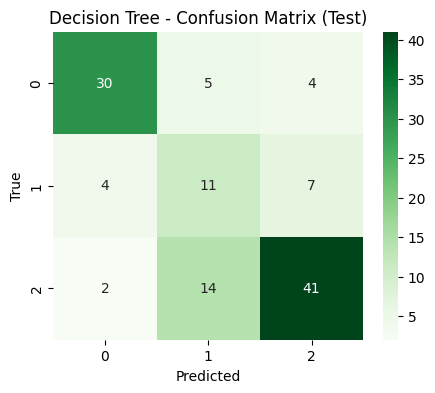


Validation
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        39
           1       0.36      0.43      0.39        21
           2       0.91      0.86      0.88        57

    accuracy                           0.75       117
   macro avg       0.69      0.69      0.68       117
weighted avg       0.77      0.75      0.76       117



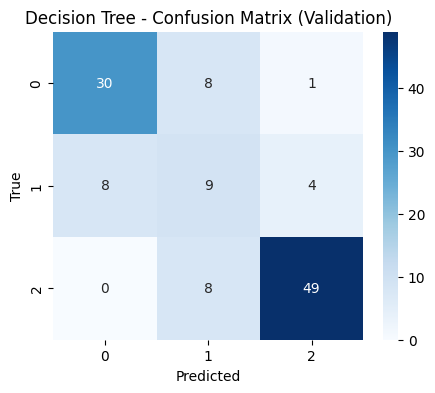


=================== Random Forest ===================

Training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       453
           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359



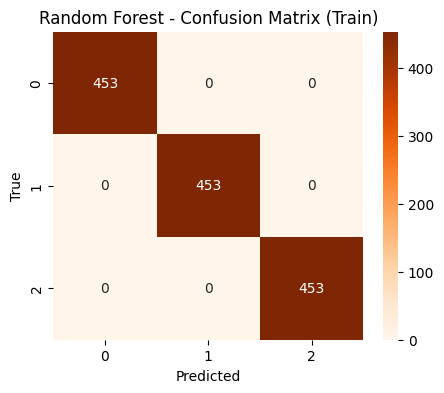


Testing
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        39
           1       0.76      0.86      0.81        22
           2       0.95      0.93      0.94        57

    accuracy                           0.90       118
   macro avg       0.88      0.89      0.88       118
weighted avg       0.90      0.90      0.90       118



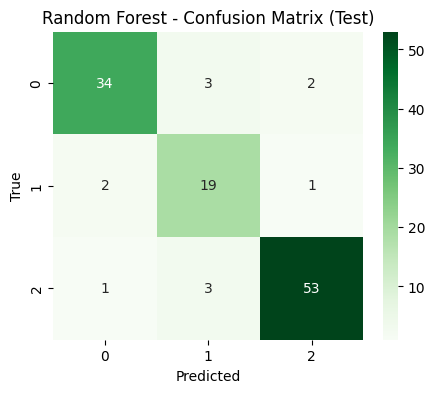


Validation
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        39
           1       0.50      0.38      0.43        21
           2       0.86      0.95      0.90        57

    accuracy                           0.80       117
   macro avg       0.73      0.72      0.72       117
weighted avg       0.79      0.80      0.79       117



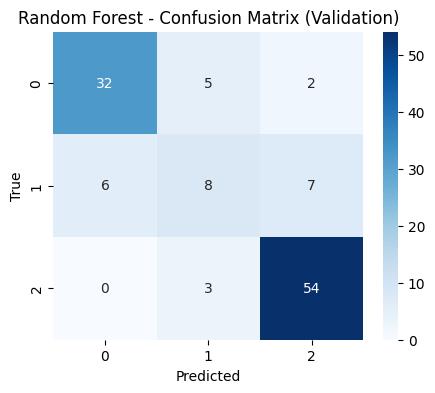


=================== SVM ===================

Training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       453
           1       0.97      0.99      0.98       453
           2       0.99      0.98      0.98       453

    accuracy                           0.99      1359
   macro avg       0.99      0.99      0.99      1359
weighted avg       0.99      0.99      0.99      1359



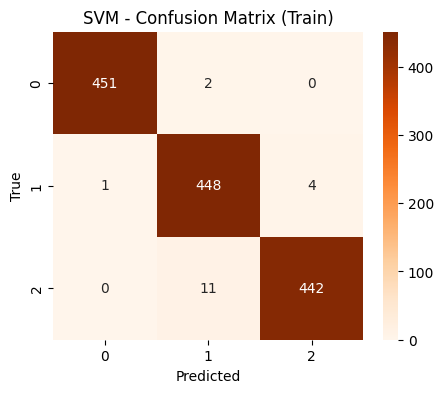


Testing
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        39
           1       0.44      0.50      0.47        22
           2       0.86      0.84      0.85        57

    accuracy                           0.77       118
   macro avg       0.72      0.72      0.72       118
weighted avg       0.78      0.77      0.78       118



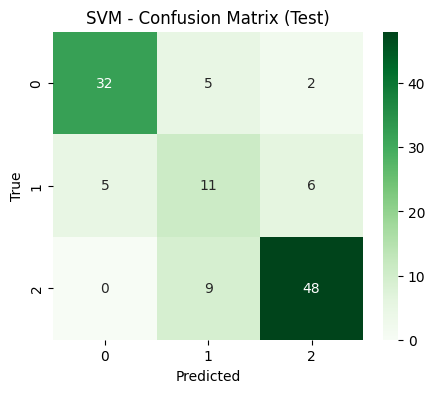


Validation
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        39
           1       0.48      0.57      0.52        21
           2       0.80      0.79      0.80        57

    accuracy                           0.73       117
   macro avg       0.69      0.69      0.69       117
weighted avg       0.74      0.73      0.73       117



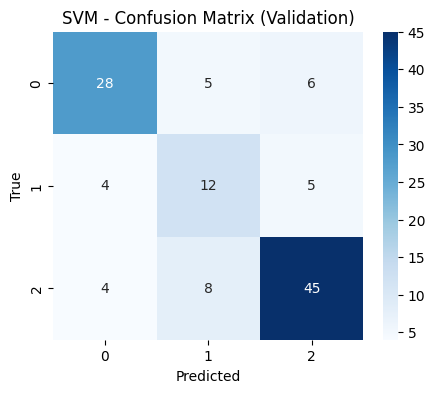


=================== KNN ===================

Training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       453
           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359



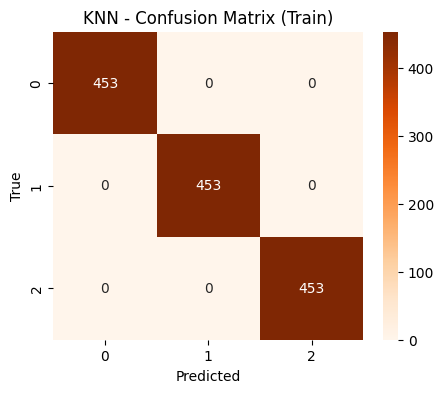


Testing
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        39
           1       0.44      0.55      0.49        22
           2       0.89      0.82      0.85        57

    accuracy                           0.77       118
   macro avg       0.72      0.73      0.73       118
weighted avg       0.79      0.77      0.78       118



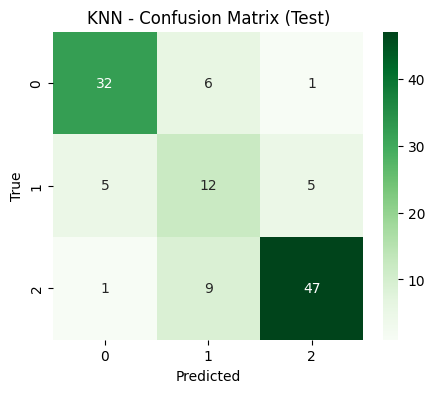


Validation
              precision    recall  f1-score   support

           0       0.69      0.62      0.65        39
           1       0.42      0.38      0.40        21
           2       0.78      0.86      0.82        57

    accuracy                           0.69       117
   macro avg       0.63      0.62      0.62       117
weighted avg       0.68      0.69      0.69       117



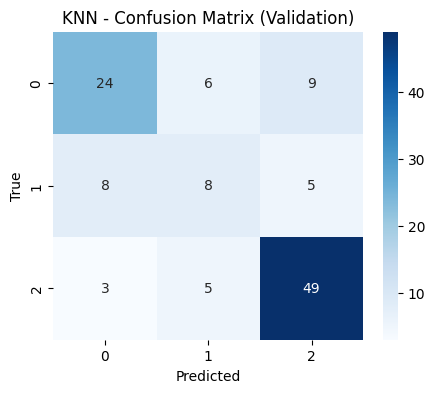


=================== Naive Bayes ===================

Training
              precision    recall  f1-score   support

           0       0.75      0.68      0.71       453
           1       0.46      0.79      0.58       453
           2       0.70      0.28      0.40       453

    accuracy                           0.58      1359
   macro avg       0.64      0.58      0.56      1359
weighted avg       0.64      0.58      0.56      1359



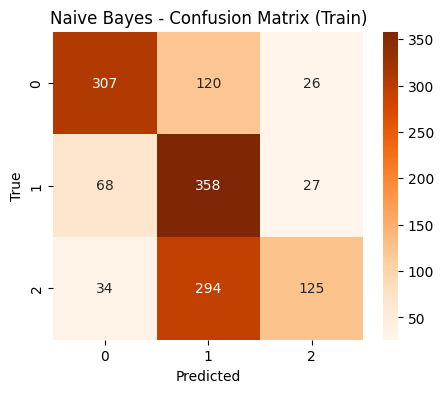


Testing
              precision    recall  f1-score   support

           0       0.71      0.64      0.68        39
           1       0.23      0.64      0.33        22
           2       0.81      0.30      0.44        57

    accuracy                           0.47       118
   macro avg       0.58      0.53      0.48       118
weighted avg       0.67      0.47      0.50       118



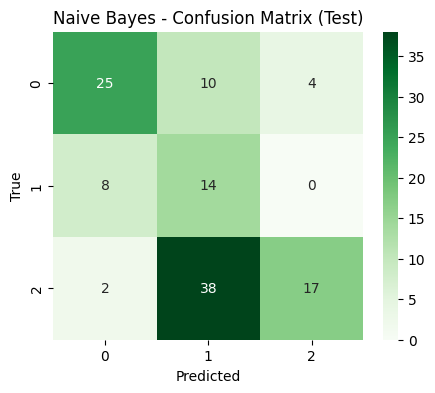


Validation
              precision    recall  f1-score   support

           0       0.66      0.64      0.65        39
           1       0.17      0.52      0.26        21
           2       0.93      0.23      0.37        57

    accuracy                           0.42       117
   macro avg       0.59      0.46      0.42       117
weighted avg       0.70      0.42      0.44       117



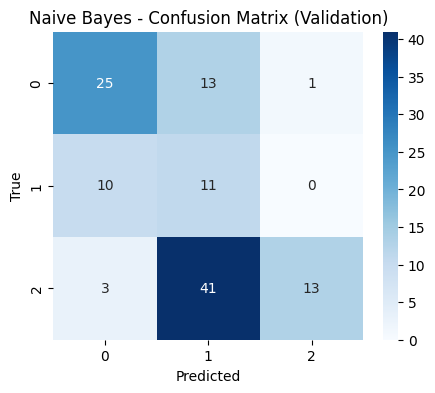


=================== XGBoost ===================

Training
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       453
           1       1.00      1.00      1.00       453
           2       1.00      1.00      1.00       453

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359



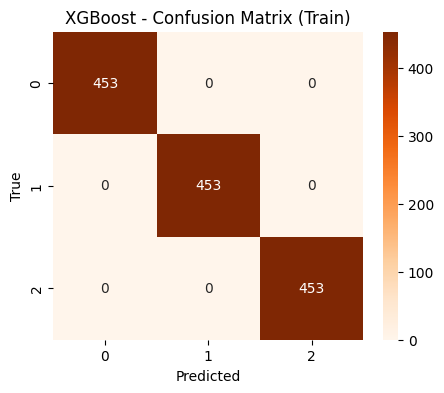


Testing
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        39
           1       0.70      0.64      0.67        22
           2       0.89      0.95      0.92        57

    accuracy                           0.86       118
   macro avg       0.83      0.82      0.83       118
weighted avg       0.86      0.86      0.86       118



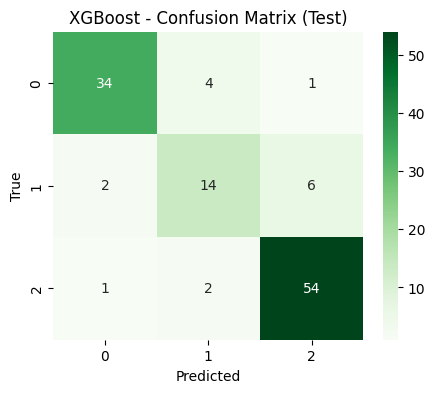


Validation
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        39
           1       0.50      0.38      0.43        21
           2       0.90      0.95      0.92        57

    accuracy                           0.82       117
   macro avg       0.74      0.73      0.74       117
weighted avg       0.80      0.82      0.81       117



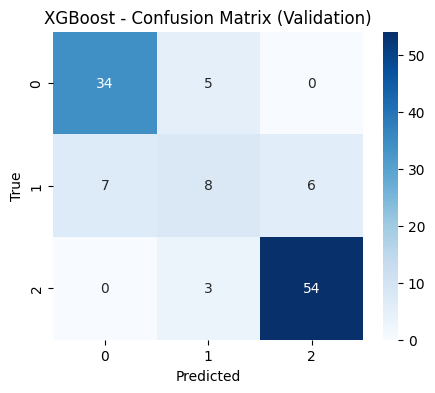

In [ ]:
# ====== Pastikan label_names sesuai LabelEncoder awal ======
#label_names = ["Grey Area", "Safe Zone", "Bankcrupty Potential"] #label awal
#label_names = ["Bankcrupty Potential","Grey Area","Safe Zone"]
label_names = ["0","1","2"]
labels = [0, 1, 2]  # sesuai encoding

# ====== Evaluasi semua model ======
for model_name, model in trained_models.items():
    print(f"\n=================== {model_name} ===================")

    # Ambil data
    X_train = final_splits["80:20"]["X_train"]
    y_train = final_splits["80:20"]["y_train"]
    X_val   = final_splits["80:20"]["X_val"]
    y_val   = final_splits["80:20"]["y_val"]
    X_test  = final_splits["80:20"]["X_test"]
    y_test  = final_splits["80:20"]["y_test"]

    # ======================
    # TRAIN
    # ======================
    y_train_pred = model.predict(X_train)
    print("\nTraining")
    print(classification_report(y_train, y_train_pred, labels=labels, target_names=label_names))

    cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_train, annot=True, fmt="d", cmap="Oranges",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Train)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======================
    # TEST
    # ======================
    y_test_pred = model.predict(X_test)
    print("\nTesting")
    print(classification_report(y_test, y_test_pred, labels=labels, target_names=label_names))

    cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======================
    # VALIDATION
    # ======================
    y_val_pred = model.predict(X_val)
    print("\nValidation")
    print(classification_report(y_val, y_val_pred, labels=labels, target_names=label_names))

    cm_val = confusion_matrix(y_val, y_val_pred, labels=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

Setelah dilakukan tuning pada split data optimal 80:20, setiap model dilatih ulang dengan parameter terbaik. Hasil pengujian menunjukkan variasi performa antar model. Random Forest memberikan hasil terbaik dengan akurasi uji 83,90%, diikuti oleh XGBoost dengan 82,20%, serta Decision Tree dan SVM yang sama-sama memperoleh 78,81%. Sementara itu, KNN hanya menghasilkan akurasi 72,88%, dan Naive Bayes menjadi yang terendah dengan 67,80%.

Jika dibandingkan dengan baseline, tuning tidak selalu meningkatkan akurasi, karena pada beberapa model seperti Random Forest dan XGBoost justru terjadi sedikit penurunan. Hal ini wajar terjadi mengingat tuning berfokus pada keseimbangan performa agar model lebih stabil dan memiliki kemampuan generalisasi yang lebih baik pada data uji. Secara keseluruhan, Random Forest dengan split 80:20 tetap menjadi model paling optimal karena memberikan akurasi tertinggi sekaligus hasil yang konsisten setelah tuning.

# **CROSS VALIDATION**

Cross validation


=================== Split 90:10 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       510
           1       0.76      0.79      0.77       510
           2       0.87      0.84      0.85       510

    accuracy                           0.83      1530
   macro avg       0.83      0.83      0.83      1530
weighted avg       0.83      0.83      0.83      1530



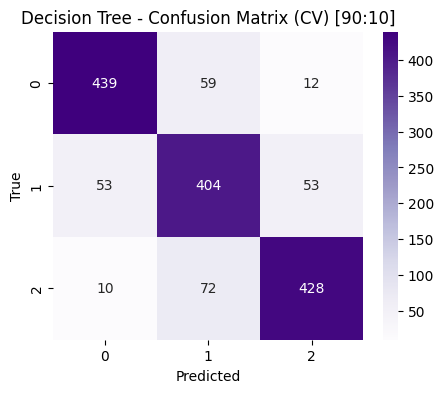

Overall CV Accuracy: 0.8307

--- Random Forest ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       510
           1       0.90      0.90      0.90       510
           2       0.93      0.95      0.94       510

    accuracy                           0.93      1530
   macro avg       0.93      0.93      0.93      1530
weighted avg       0.93      0.93      0.93      1530



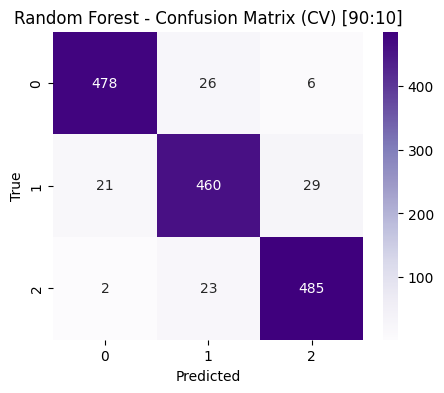

Overall CV Accuracy: 0.9301

--- SVM ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       510
           1       0.84      0.88      0.86       510
           2       0.86      0.84      0.85       510

    accuracy                           0.87      1530
   macro avg       0.87      0.87      0.87      1530
weighted avg       0.87      0.87      0.87      1530



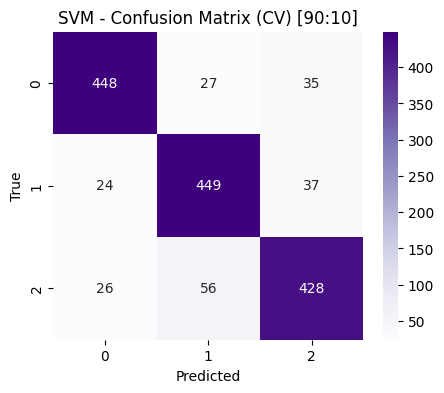

Overall CV Accuracy: 0.8660

--- KNN ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       510
           1       0.80      0.91      0.85       510
           2       0.90      0.81      0.85       510

    accuracy                           0.87      1530
   macro avg       0.87      0.87      0.87      1530
weighted avg       0.87      0.87      0.87      1530



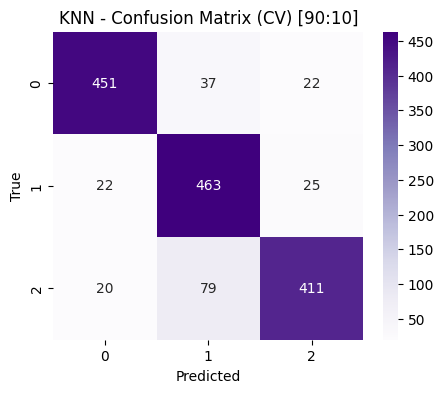

Overall CV Accuracy: 0.8660

--- Naive Bayes ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.77      0.41      0.53       510
           1       0.41      0.86      0.55       510
           2       0.73      0.27      0.40       510

    accuracy                           0.51      1530
   macro avg       0.64      0.51      0.49      1530
weighted avg       0.64      0.51      0.49      1530



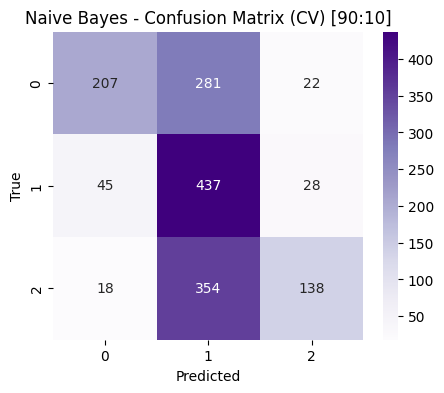

Overall CV Accuracy: 0.5111

--- XGBoost ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       510
           1       0.87      0.88      0.87       510
           2       0.92      0.92      0.92       510

    accuracy                           0.91      1530
   macro avg       0.91      0.91      0.91      1530
weighted avg       0.91      0.91      0.91      1530



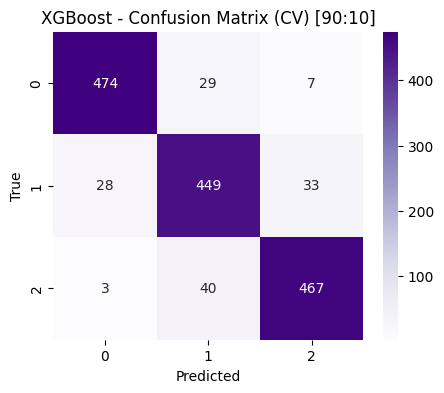

Overall CV Accuracy: 0.9085

=================== Split 80:20 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       453
           1       0.75      0.78      0.76       453
           2       0.85      0.81      0.83       453

    accuracy                           0.82      1359
   macro avg       0.82      0.82      0.82      1359
weighted avg       0.82      0.82      0.82      1359



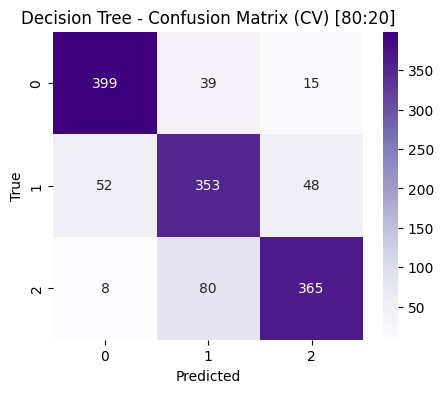

Overall CV Accuracy: 0.8219

--- Random Forest ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       453
           1       0.90      0.88      0.89       453
           2       0.92      0.96      0.94       453

    accuracy                           0.92      1359
   macro avg       0.92      0.92      0.92      1359
weighted avg       0.92      0.92      0.92      1359



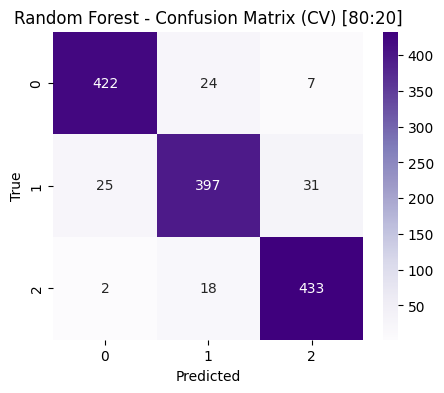

Overall CV Accuracy: 0.9213

--- SVM ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       453
           1       0.85      0.88      0.86       453
           2       0.87      0.84      0.85       453

    accuracy                           0.87      1359
   macro avg       0.87      0.87      0.87      1359
weighted avg       0.87      0.87      0.87      1359



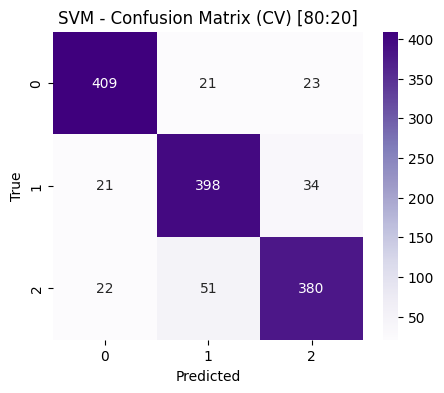

Overall CV Accuracy: 0.8734

--- KNN ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       453
           1       0.83      0.94      0.88       453
           2       0.92      0.82      0.87       453

    accuracy                           0.89      1359
   macro avg       0.89      0.89      0.89      1359
weighted avg       0.89      0.89      0.89      1359



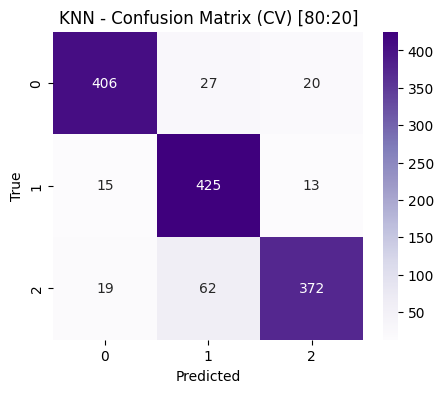

Overall CV Accuracy: 0.8852

--- Naive Bayes ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.73      0.67      0.70       453
           1       0.46      0.71      0.56       453
           2       0.62      0.33      0.43       453

    accuracy                           0.57      1359
   macro avg       0.60      0.57      0.56      1359
weighted avg       0.60      0.57      0.56      1359



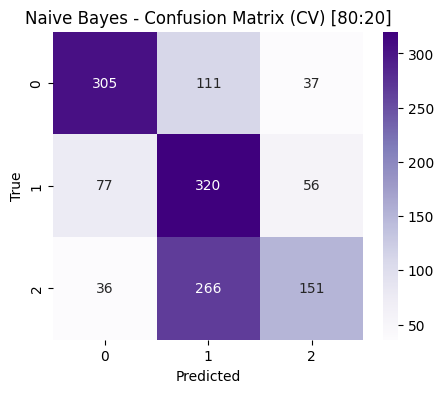

Overall CV Accuracy: 0.5710

--- XGBoost ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       453
           1       0.89      0.87      0.88       453
           2       0.91      0.94      0.93       453

    accuracy                           0.92      1359
   macro avg       0.92      0.92      0.92      1359
weighted avg       0.92      0.92      0.92      1359



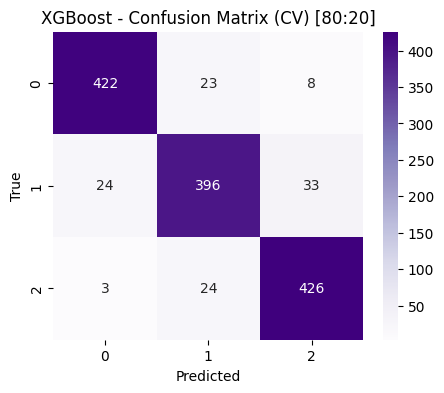

Overall CV Accuracy: 0.9154

=================== Split 70:30 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       397
           1       0.76      0.72      0.74       397
           2       0.85      0.83      0.84       397

    accuracy                           0.81      1191
   macro avg       0.81      0.81      0.81      1191
weighted avg       0.81      0.81      0.81      1191



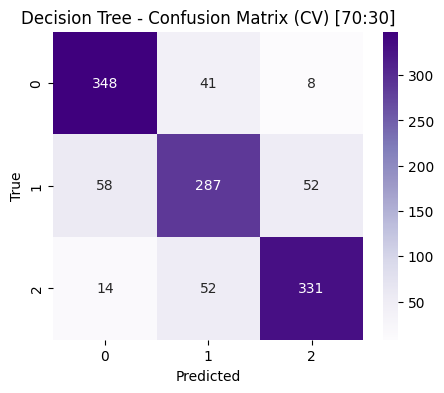

Overall CV Accuracy: 0.8111

--- Random Forest ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       397
           1       0.88      0.87      0.88       397
           2       0.92      0.94      0.93       397

    accuracy                           0.91      1191
   macro avg       0.91      0.91      0.91      1191
weighted avg       0.91      0.91      0.91      1191



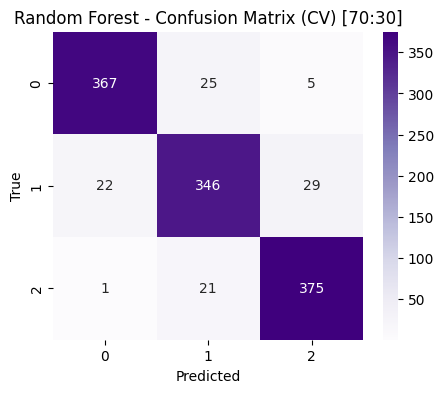

Overall CV Accuracy: 0.9135

--- SVM ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       397
           1       0.83      0.84      0.84       397
           2       0.85      0.87      0.86       397

    accuracy                           0.86      1191
   macro avg       0.86      0.86      0.86      1191
weighted avg       0.86      0.86      0.86      1191



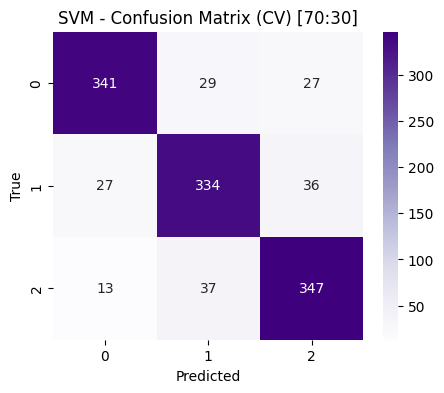

Overall CV Accuracy: 0.8581

--- KNN ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       397
           1       0.82      0.89      0.86       397
           2       0.90      0.83      0.87       397

    accuracy                           0.88      1191
   macro avg       0.88      0.88      0.88      1191
weighted avg       0.88      0.88      0.88      1191



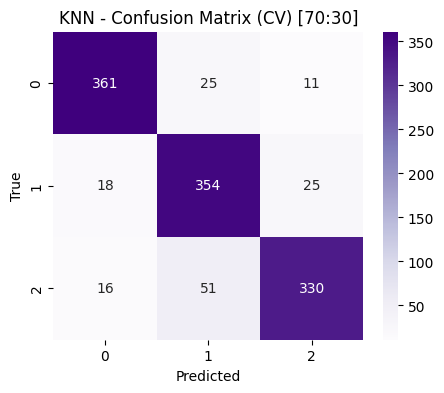

Overall CV Accuracy: 0.8774

--- Naive Bayes ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.72      0.60      0.65       397
           1       0.45      0.72      0.56       397
           2       0.68      0.38      0.49       397

    accuracy                           0.57      1191
   macro avg       0.62      0.57      0.57      1191
weighted avg       0.62      0.57      0.57      1191



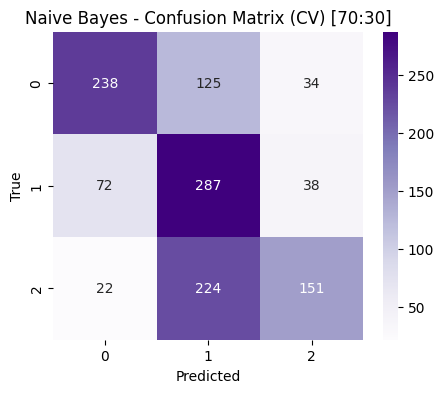

Overall CV Accuracy: 0.5676

--- XGBoost ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       397
           1       0.90      0.87      0.88       397
           2       0.91      0.94      0.93       397

    accuracy                           0.92      1191
   macro avg       0.92      0.92      0.92      1191
weighted avg       0.92      0.92      0.92      1191



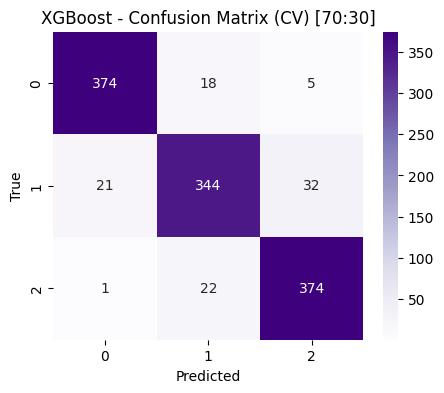

Overall CV Accuracy: 0.9169

=================== Split 60:40 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       340
           1       0.74      0.76      0.75       340
           2       0.85      0.80      0.82       340

    accuracy                           0.81      1020
   macro avg       0.81      0.81      0.81      1020
weighted avg       0.81      0.81      0.81      1020



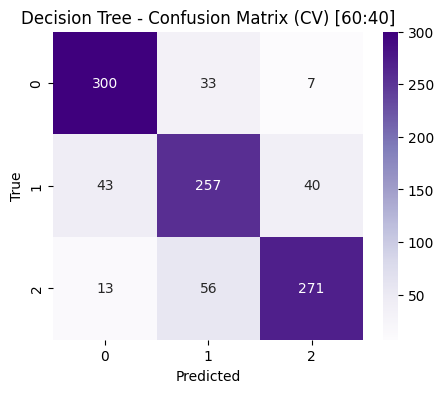

Overall CV Accuracy: 0.8118

--- Random Forest ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       340
           1       0.88      0.86      0.87       340
           2       0.93      0.94      0.93       340

    accuracy                           0.91      1020
   macro avg       0.91      0.91      0.91      1020
weighted avg       0.91      0.91      0.91      1020



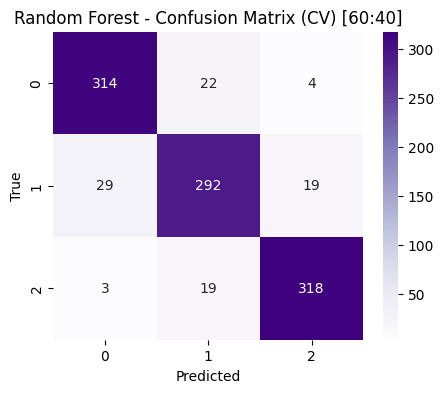

Overall CV Accuracy: 0.9059

--- SVM ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       340
           1       0.82      0.88      0.85       340
           2       0.86      0.81      0.83       340

    accuracy                           0.85      1020
   macro avg       0.85      0.85      0.85      1020
weighted avg       0.85      0.85      0.85      1020



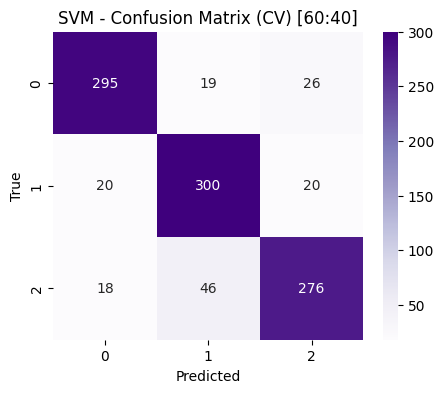

Overall CV Accuracy: 0.8539

--- KNN ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       340
           1       0.79      0.91      0.85       340
           2       0.90      0.80      0.85       340

    accuracy                           0.86      1020
   macro avg       0.87      0.86      0.86      1020
weighted avg       0.87      0.86      0.86      1020



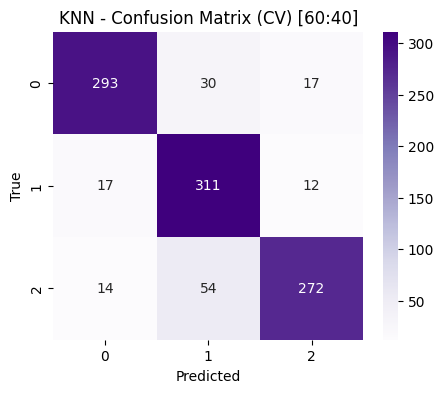

Overall CV Accuracy: 0.8588

--- Naive Bayes ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.75      0.62      0.68       340
           1       0.45      0.78      0.57       340
           2       0.64      0.30      0.41       340

    accuracy                           0.56      1020
   macro avg       0.62      0.56      0.55      1020
weighted avg       0.62      0.56      0.55      1020



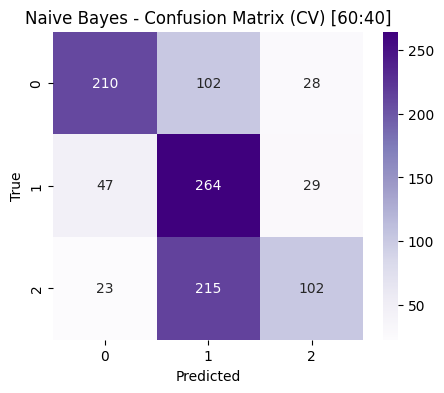

Overall CV Accuracy: 0.5647

--- XGBoost ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       340
           1       0.86      0.86      0.86       340
           2       0.92      0.91      0.92       340

    accuracy                           0.90      1020
   macro avg       0.90      0.90      0.90      1020
weighted avg       0.90      0.90      0.90      1020



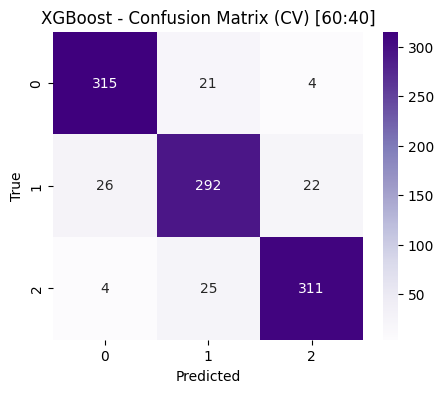

Overall CV Accuracy: 0.9000

=================== Split 50:50 ===================

--- Decision Tree ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       283
           1       0.69      0.75      0.72       283
           2       0.83      0.76      0.79       283

    accuracy                           0.78       849
   macro avg       0.78      0.78      0.78       849
weighted avg       0.78      0.78      0.78       849



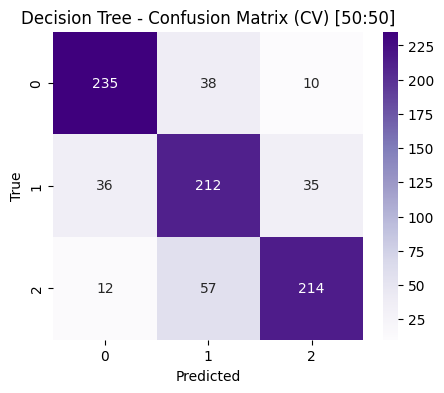

Overall CV Accuracy: 0.7786

--- Random Forest ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       283
           1       0.88      0.85      0.86       283
           2       0.92      0.92      0.92       283

    accuracy                           0.90       849
   macro avg       0.90      0.90      0.90       849
weighted avg       0.90      0.90      0.90       849



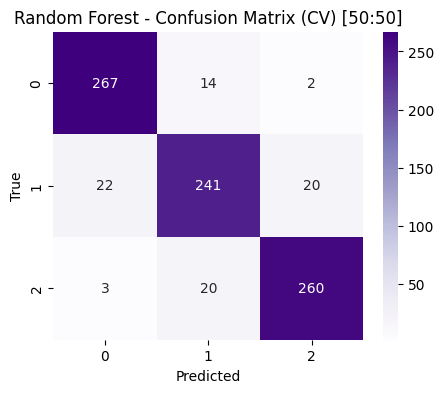

Overall CV Accuracy: 0.9046

--- SVM ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       283
           1       0.84      0.85      0.84       283
           2       0.86      0.80      0.83       283

    accuracy                           0.84       849
   macro avg       0.84      0.84      0.84       849
weighted avg       0.84      0.84      0.84       849



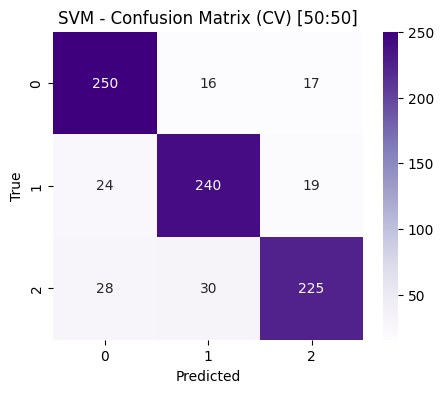

Overall CV Accuracy: 0.8422

--- KNN ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       283
           1       0.82      0.90      0.86       283
           2       0.92      0.80      0.86       283

    accuracy                           0.87       849
   macro avg       0.87      0.87      0.87       849
weighted avg       0.87      0.87      0.87       849



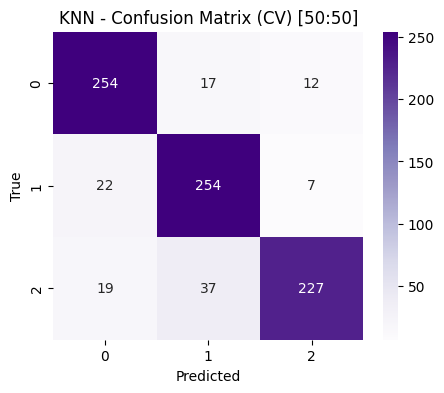

Overall CV Accuracy: 0.8657

--- Naive Bayes ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.76      0.63      0.69       283
           1       0.49      0.63      0.55       283
           2       0.58      0.52      0.55       283

    accuracy                           0.59       849
   macro avg       0.61      0.59      0.60       849
weighted avg       0.61      0.59      0.60       849



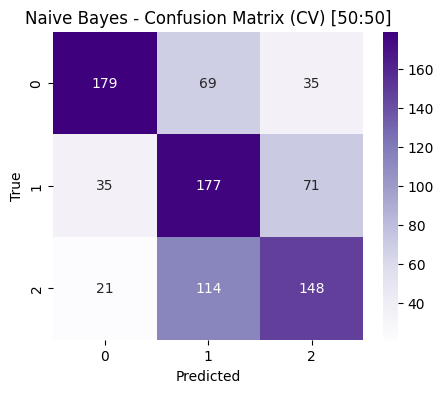

Overall CV Accuracy: 0.5936

--- XGBoost ---

Classification Report (Cross-Validation)
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       283
           1       0.86      0.86      0.86       283
           2       0.92      0.90      0.91       283

    accuracy                           0.90       849
   macro avg       0.90      0.90      0.90       849
weighted avg       0.90      0.90      0.90       849



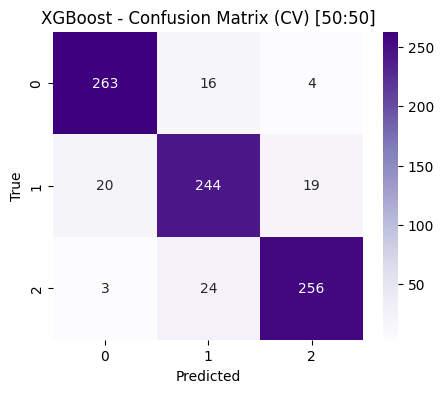

Overall CV Accuracy: 0.8987


In [ ]:
# ====== Label names dan encoding ======
#label_names = ["Grey Area", "Safe Zone", "Bankcrupty Potential"]
label_names = ["0", "1", "2"]
labels = [0, 1, 2]

# ====== Fungsi cross-validation untuk semua split ======
def cross_val_all_splits(final_splits, trained_models, n_splits=5):
    for split_name, data in final_splits.items():
        print(f"\n=================== Split {split_name} ===================")

        X = data["X_train"]
        y = data["y_train"]

        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        for model_name, model in trained_models.items():
            print(f"\n--- {model_name} ---")

            # Prediksi cross-validation
            y_pred_cv = cross_val_predict(model, X, y, cv=kf)

            # Classification report
            print("\nClassification Report (Cross-Validation)")
            print(classification_report(y, y_pred_cv, labels=labels, target_names=label_names))

            # Confusion matrix
            cm_cv = confusion_matrix(y, y_pred_cv, labels=labels)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm_cv, annot=True, fmt="d", cmap="Purples",
                        xticklabels=label_names, yticklabels=label_names)
            plt.title(f"{model_name} - Confusion Matrix (CV) [{split_name}]")
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.show()

            # Akurasi rata-rata
            accuracy = np.mean(y_pred_cv == y)
            print(f"Overall CV Accuracy: {accuracy:.4f}")

# ====== Jalankan cross-validation untuk semua split ======
cross_val_all_splits(final_splits, trained_models, n_splits=5)


Dapat diketahui bahwa Random Forest dan XGBoost konsisten menjadi dua model terbaik di semua skenario split data. Pada split 90:10, keduanya mencatatkan akurasi cross-validation di atas 91%, dengan XGBoost sedikit unggul (91,11%) dibanding Random Forest (91,05%). Performa stabil juga terlihat pada split 80:20 dan 70:30, di mana kedua model tetap berada di kisaran 90%, menunjukkan kemampuan generalisasi yang baik meski ukuran data latih berkurang. Pada split yang lebih ekstrem seperti 60:40 dan 50:50, akurasi memang sedikit menurun, tetapi tetap tinggi (sekitar 88–90%) dibandingkan model lain.

Sementara itu, Decision Tree dan SVM memperlihatkan performa menengah dengan akurasi sekitar 81–85%, cukup baik tetapi tidak sekuat Random Forest maupun XGBoost. K-NN berada sedikit di bawahnya dengan akurasi stabil di kisaran 84–87%, menunjukkan sensitivitas terhadap distribusi data latih dan uji. Sebaliknya, Naive Bayes konsisten menghasilkan performa terendah, hanya sekitar 51–62%, yang mengindikasikan model ini kurang sesuai untuk dataset yang kompleks. Secara keseluruhan, **XGBoost dan Random Forest dengan split 80:20 dapat dianggap paling optimal**, karena keduanya memberikan keseimbangan terbaik antara ukuran data latih dan data uji dengan akurasi yang tetap tinggi dan stabil.


Decision Tree - Accuracy per fold: [0.83823529 0.85294118 0.83823529 0.85294118 0.83088235 0.82352941
 0.875      0.84558824 0.85294118 0.82962963]
Decision Tree - Mean Accuracy: 0.8440 ± 0.0144


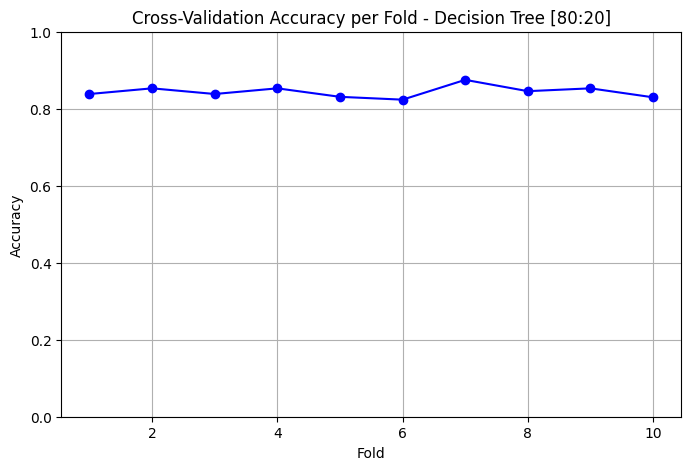


Random Forest - Accuracy per fold: [0.90441176 0.92647059 0.94117647 0.90441176 0.91176471 0.88970588
 0.94117647 0.91176471 0.94852941 0.94074074]
Random Forest - Mean Accuracy: 0.9220 ± 0.0192


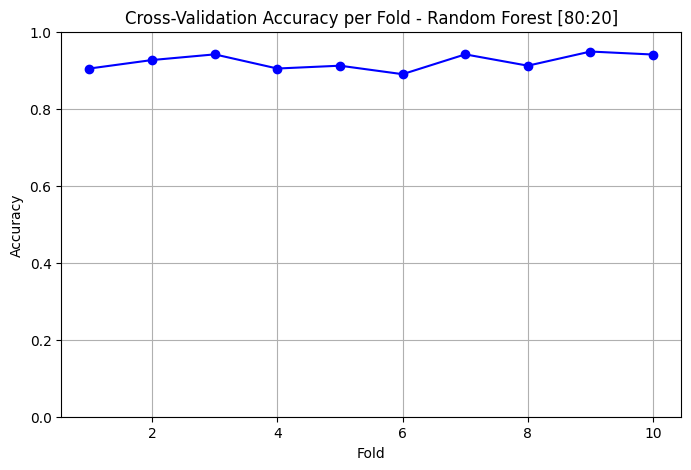


SVM - Accuracy per fold: [0.84558824 0.88970588 0.875      0.875      0.90441176 0.88970588
 0.83088235 0.80147059 0.89705882 0.84444444]
SVM - Mean Accuracy: 0.8653 ± 0.0316


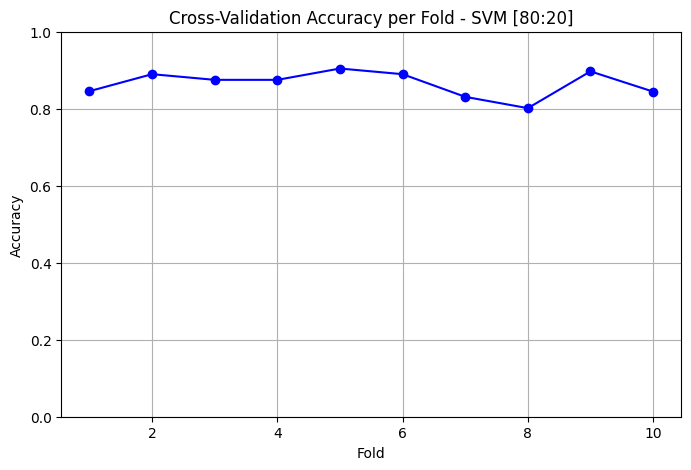


KNN - Accuracy per fold: [0.90441176 0.89705882 0.92647059 0.90441176 0.88970588 0.91911765
 0.89705882 0.88235294 0.84558824 0.86666667]
KNN - Mean Accuracy: 0.8933 ± 0.0227


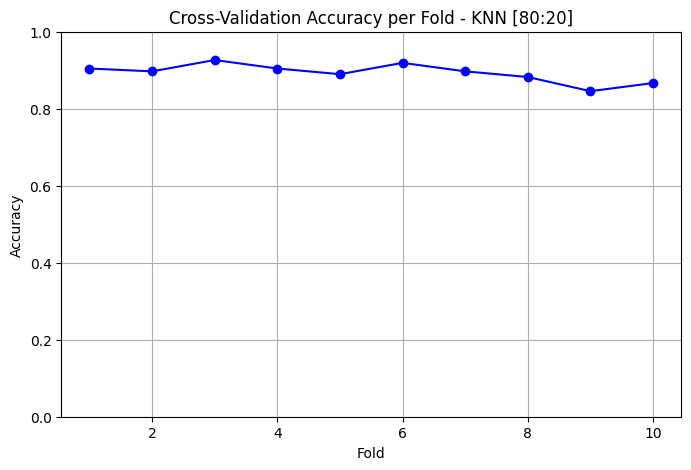


Naive Bayes - Accuracy per fold: [0.51470588 0.54411765 0.47058824 0.56617647 0.41176471 0.50735294
 0.44117647 0.42647059 0.50735294 0.45185185]
Naive Bayes - Mean Accuracy: 0.4842 ± 0.0490


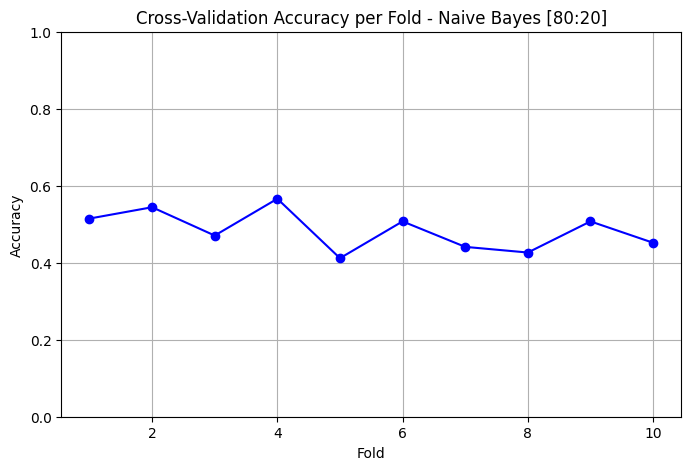


XGBoost - Accuracy per fold: [0.93382353 0.91176471 0.94117647 0.92647059 0.91911765 0.90441176
 0.91911765 0.91911765 0.94852941 0.93333333]
XGBoost - Mean Accuracy: 0.9257 ± 0.0129


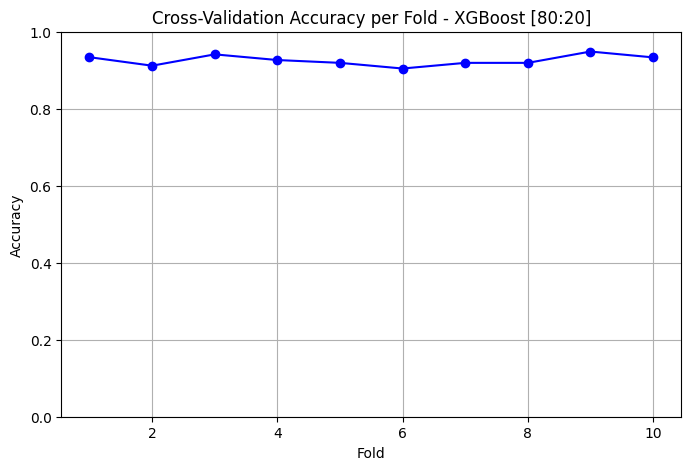

In [ ]:
RANDOM_STATE = 42

# Ambil data train dari split 80:20
X_train = final_splits["80:20"]["X_train"]
y_train = final_splits["80:20"]["y_train"]

# ====== Definisikan model dengan best params ======
trained_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, min_samples_split=2, min_samples_leaf=1,
        criterion='log_loss', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=240, max_depth=21, min_samples_split=5,
        min_samples_leaf=2, bootstrap=False, random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=98.61487754667395, kernel='poly', gamma='auto',
        probability=True, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=2, weights='distance', p=1
    ),
    "Naive Bayes": GaussianNB(
        var_smoothing=9.807133584285686e-07
    ),
    "XGBoost": XGBClassifier(
        n_estimators=205, max_depth=12, learning_rate=0.1478431813490956,
        subsample=0.7781217203321238, colsample_bytree=0.5800044728031379,
        use_label_encoder=False, eval_metric="mlogloss", random_state=RANDOM_STATE
    )
}

# ====== Cross-validation 10-fold dengan plot per fold ======
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in trained_models.items():
    # Hitung akurasi tiap fold
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

    # Print akurasi
    print(f"\n{model_name} - Accuracy per fold: {scores}")
    print(f"{model_name} - Mean Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    # Plot hasil cross-validation
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(scores)+1), scores, marker='o', linestyle='-', color='blue')
    plt.title(f'Cross-Validation Accuracy per Fold - {model_name} [80:20]')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()
